In [6]:
from prepare_time_boroughs import prepare_yearly_boroughs, prepare_quarterly_boroughs, prepare_monthly_boroughs
from forecasting_class import Forecast
import pandas as pd
import matplotlib.pyplot as plt

/opt/anaconda3/envs/london/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


In [7]:
df_year = prepare_yearly_boroughs()
df_quarter = prepare_quarterly_boroughs()
df_month = prepare_monthly_boroughs()

PREPARING YEARLY DATA...
COMPLETE
PREPARING QUARTERLY DATA...
COMPLETE
PREPARING MONTHLY DATA...
COMPLETE


15:15:22 - cmdstanpy - INFO - Chain [1] start processing
15:15:22 - cmdstanpy - INFO - Chain [1] done processing
15:15:22 - cmdstanpy - INFO - Chain [1] start processing
15:15:22 - cmdstanpy - INFO - Chain [1] done processing
15:15:22 - cmdstanpy - INFO - Chain [1] start processing
15:15:22 - cmdstanpy - INFO - Chain [1] done processing
15:15:22 - cmdstanpy - INFO - Chain [1] start processing
15:15:23 - cmdstanpy - INFO - Chain [1] done processing
15:15:23 - cmdstanpy - INFO - Chain [1] start processing
15:15:23 - cmdstanpy - INFO - Chain [1] done processing
15:15:23 - cmdstanpy - INFO - Chain [1] start processing
15:15:23 - cmdstanpy - INFO - Chain [1] done processing
15:15:23 - cmdstanpy - INFO - Chain [1] start processing
15:15:23 - cmdstanpy - INFO - Chain [1] done processing
15:15:23 - cmdstanpy - INFO - Chain [1] start processing
15:15:23 - cmdstanpy - INFO - Chain [1] done processing
15:15:23 - cmdstanpy - INFO - Chain [1] start processing
15:15:23 - cmdstanpy - INFO - Chain [1]

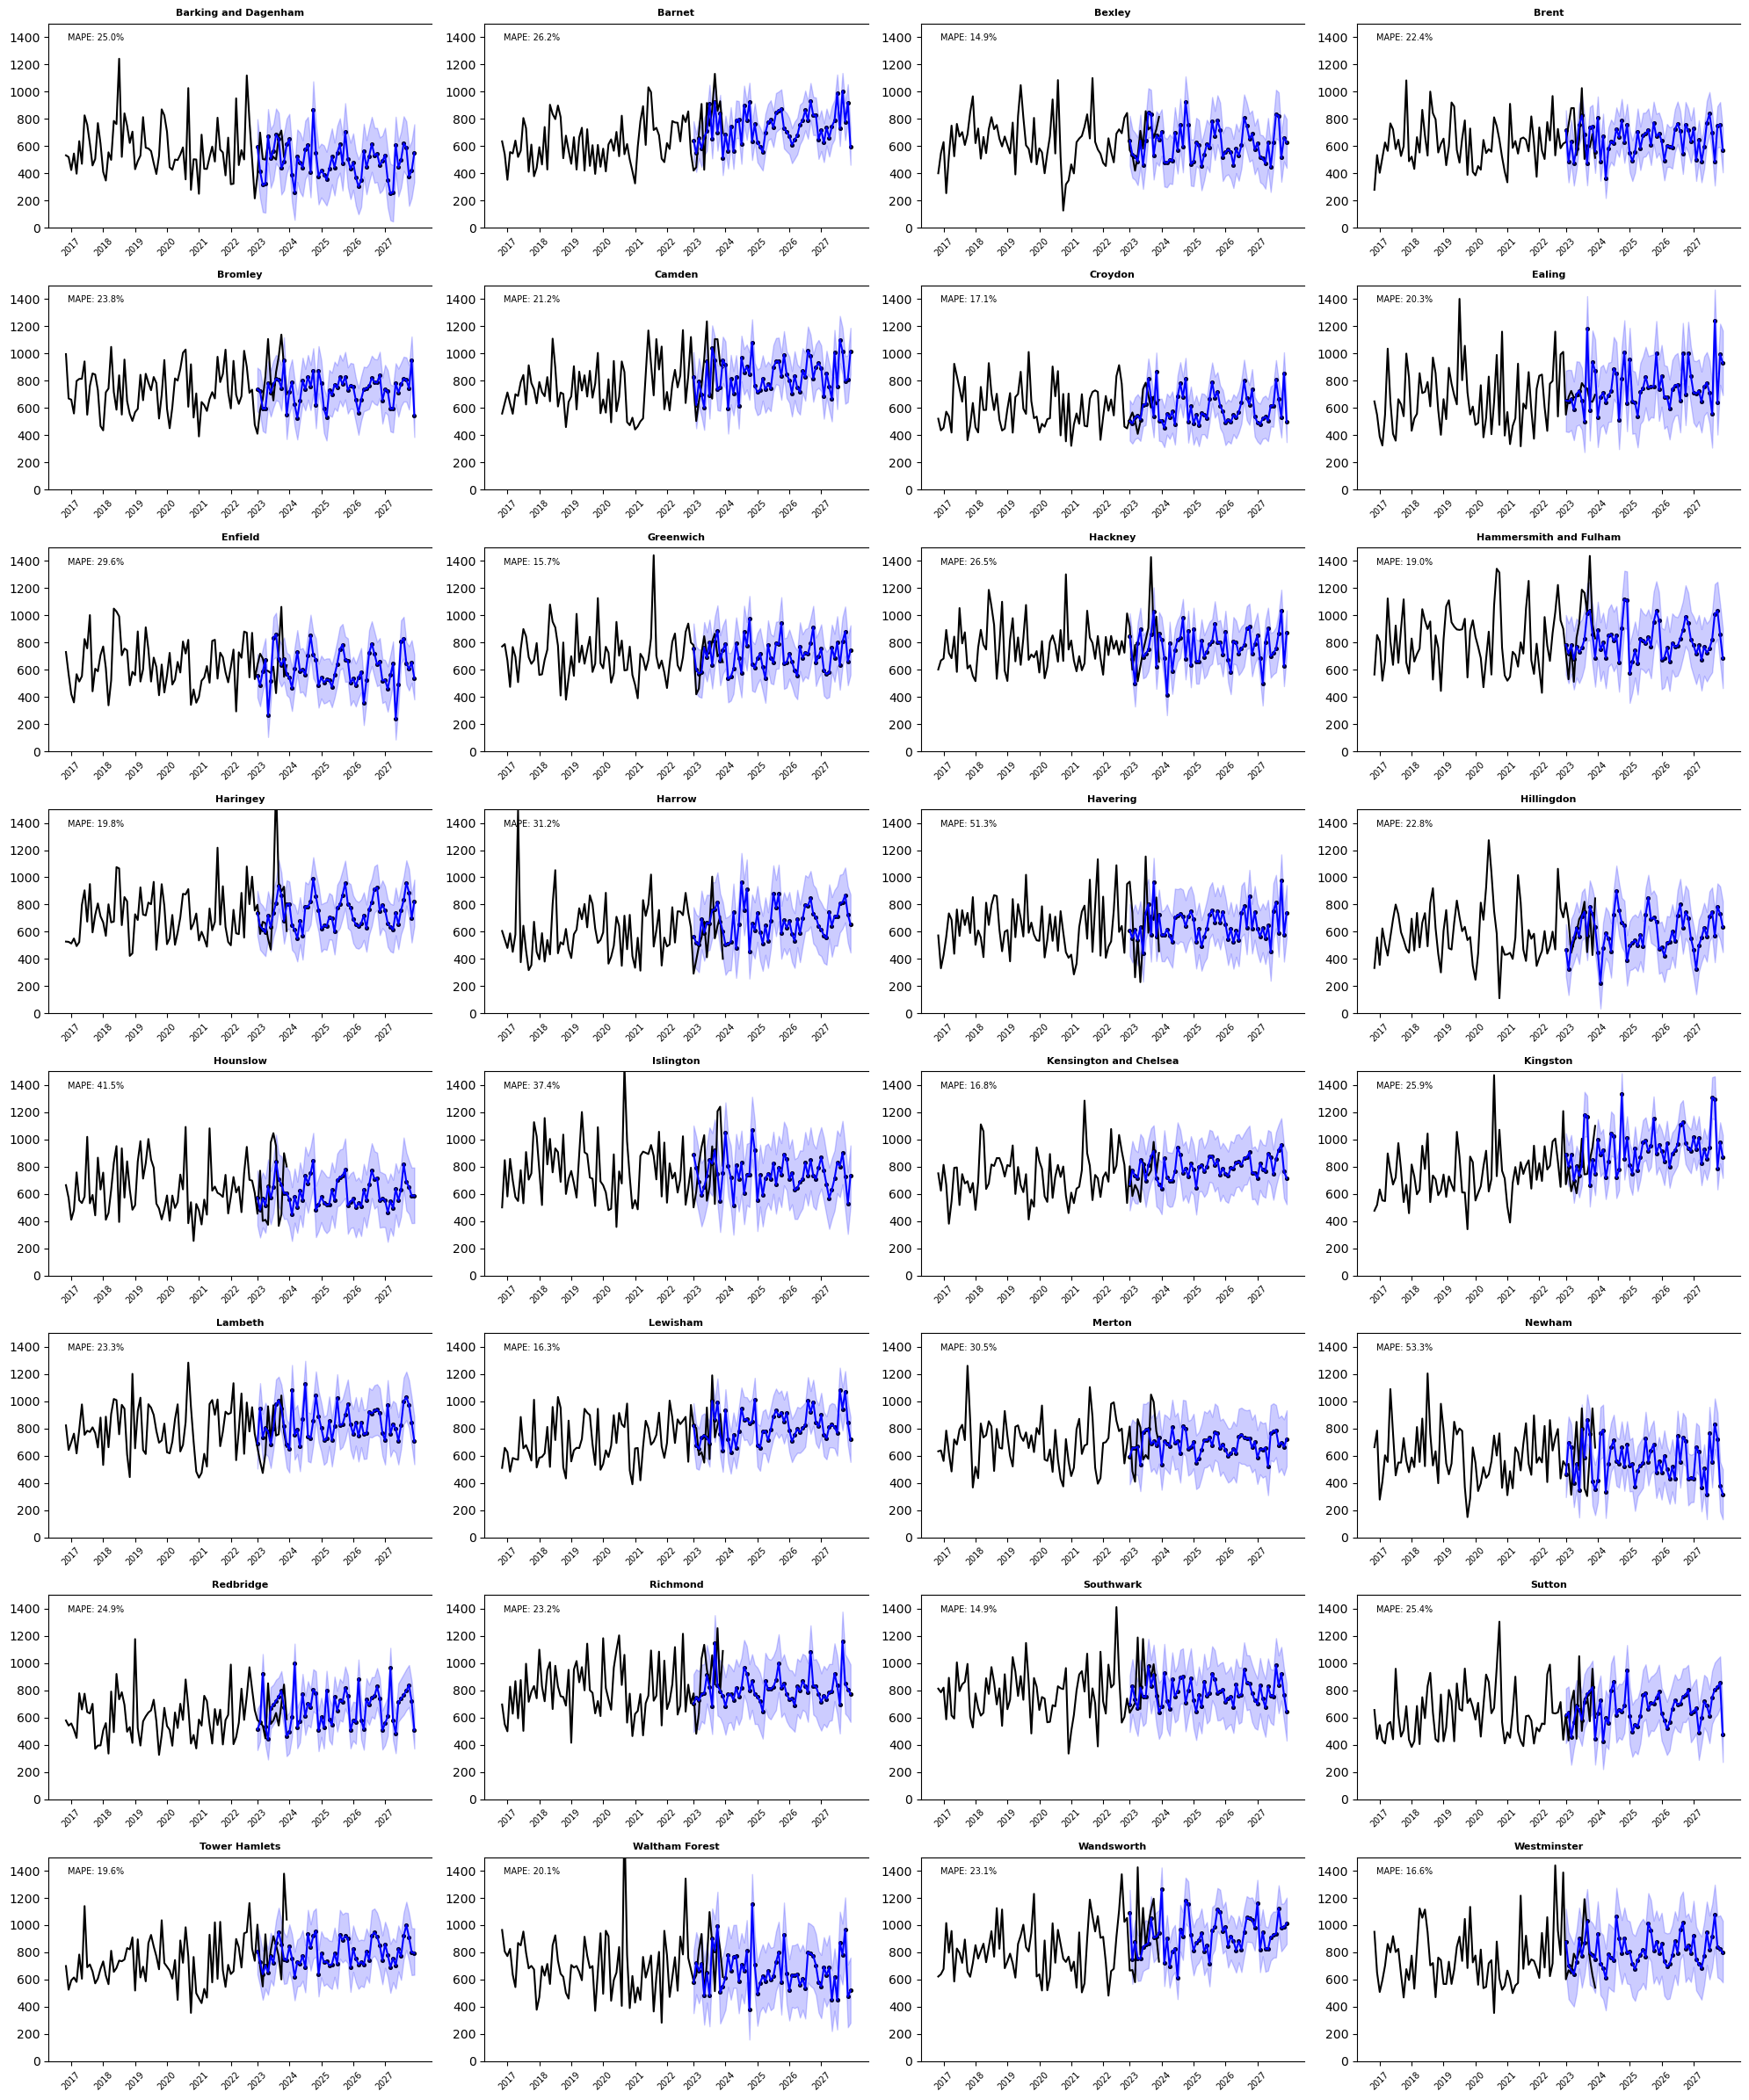

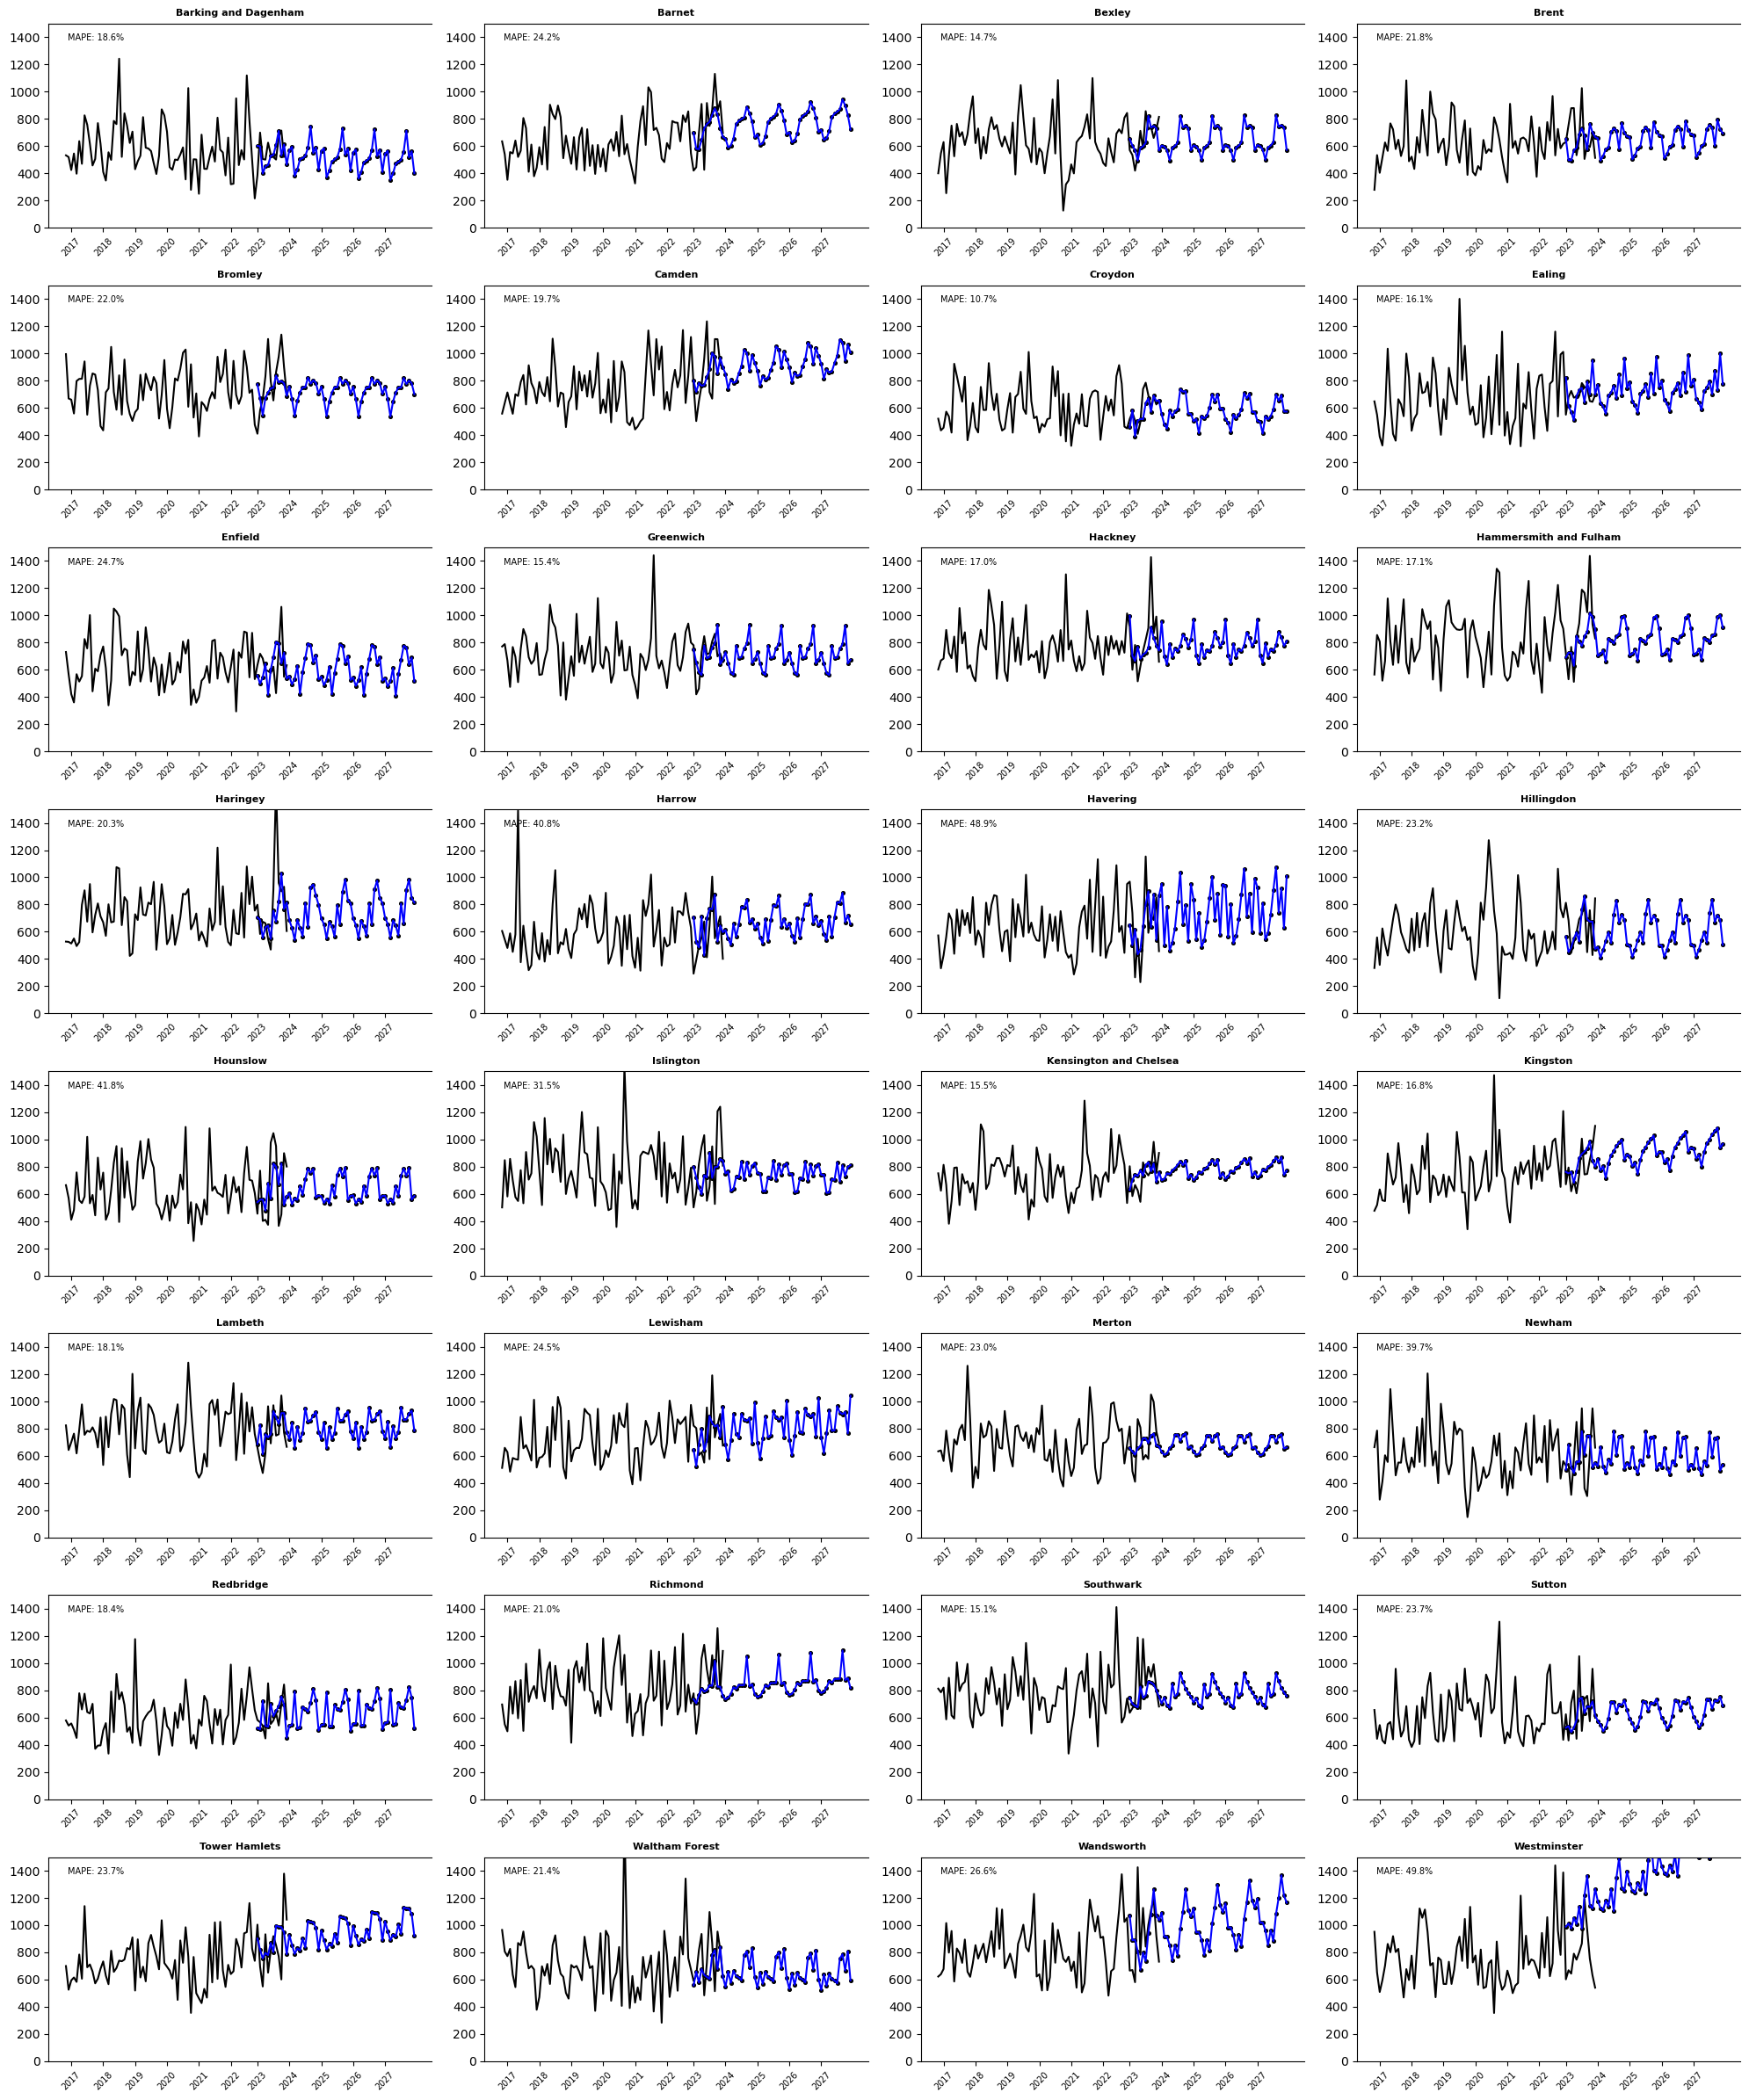

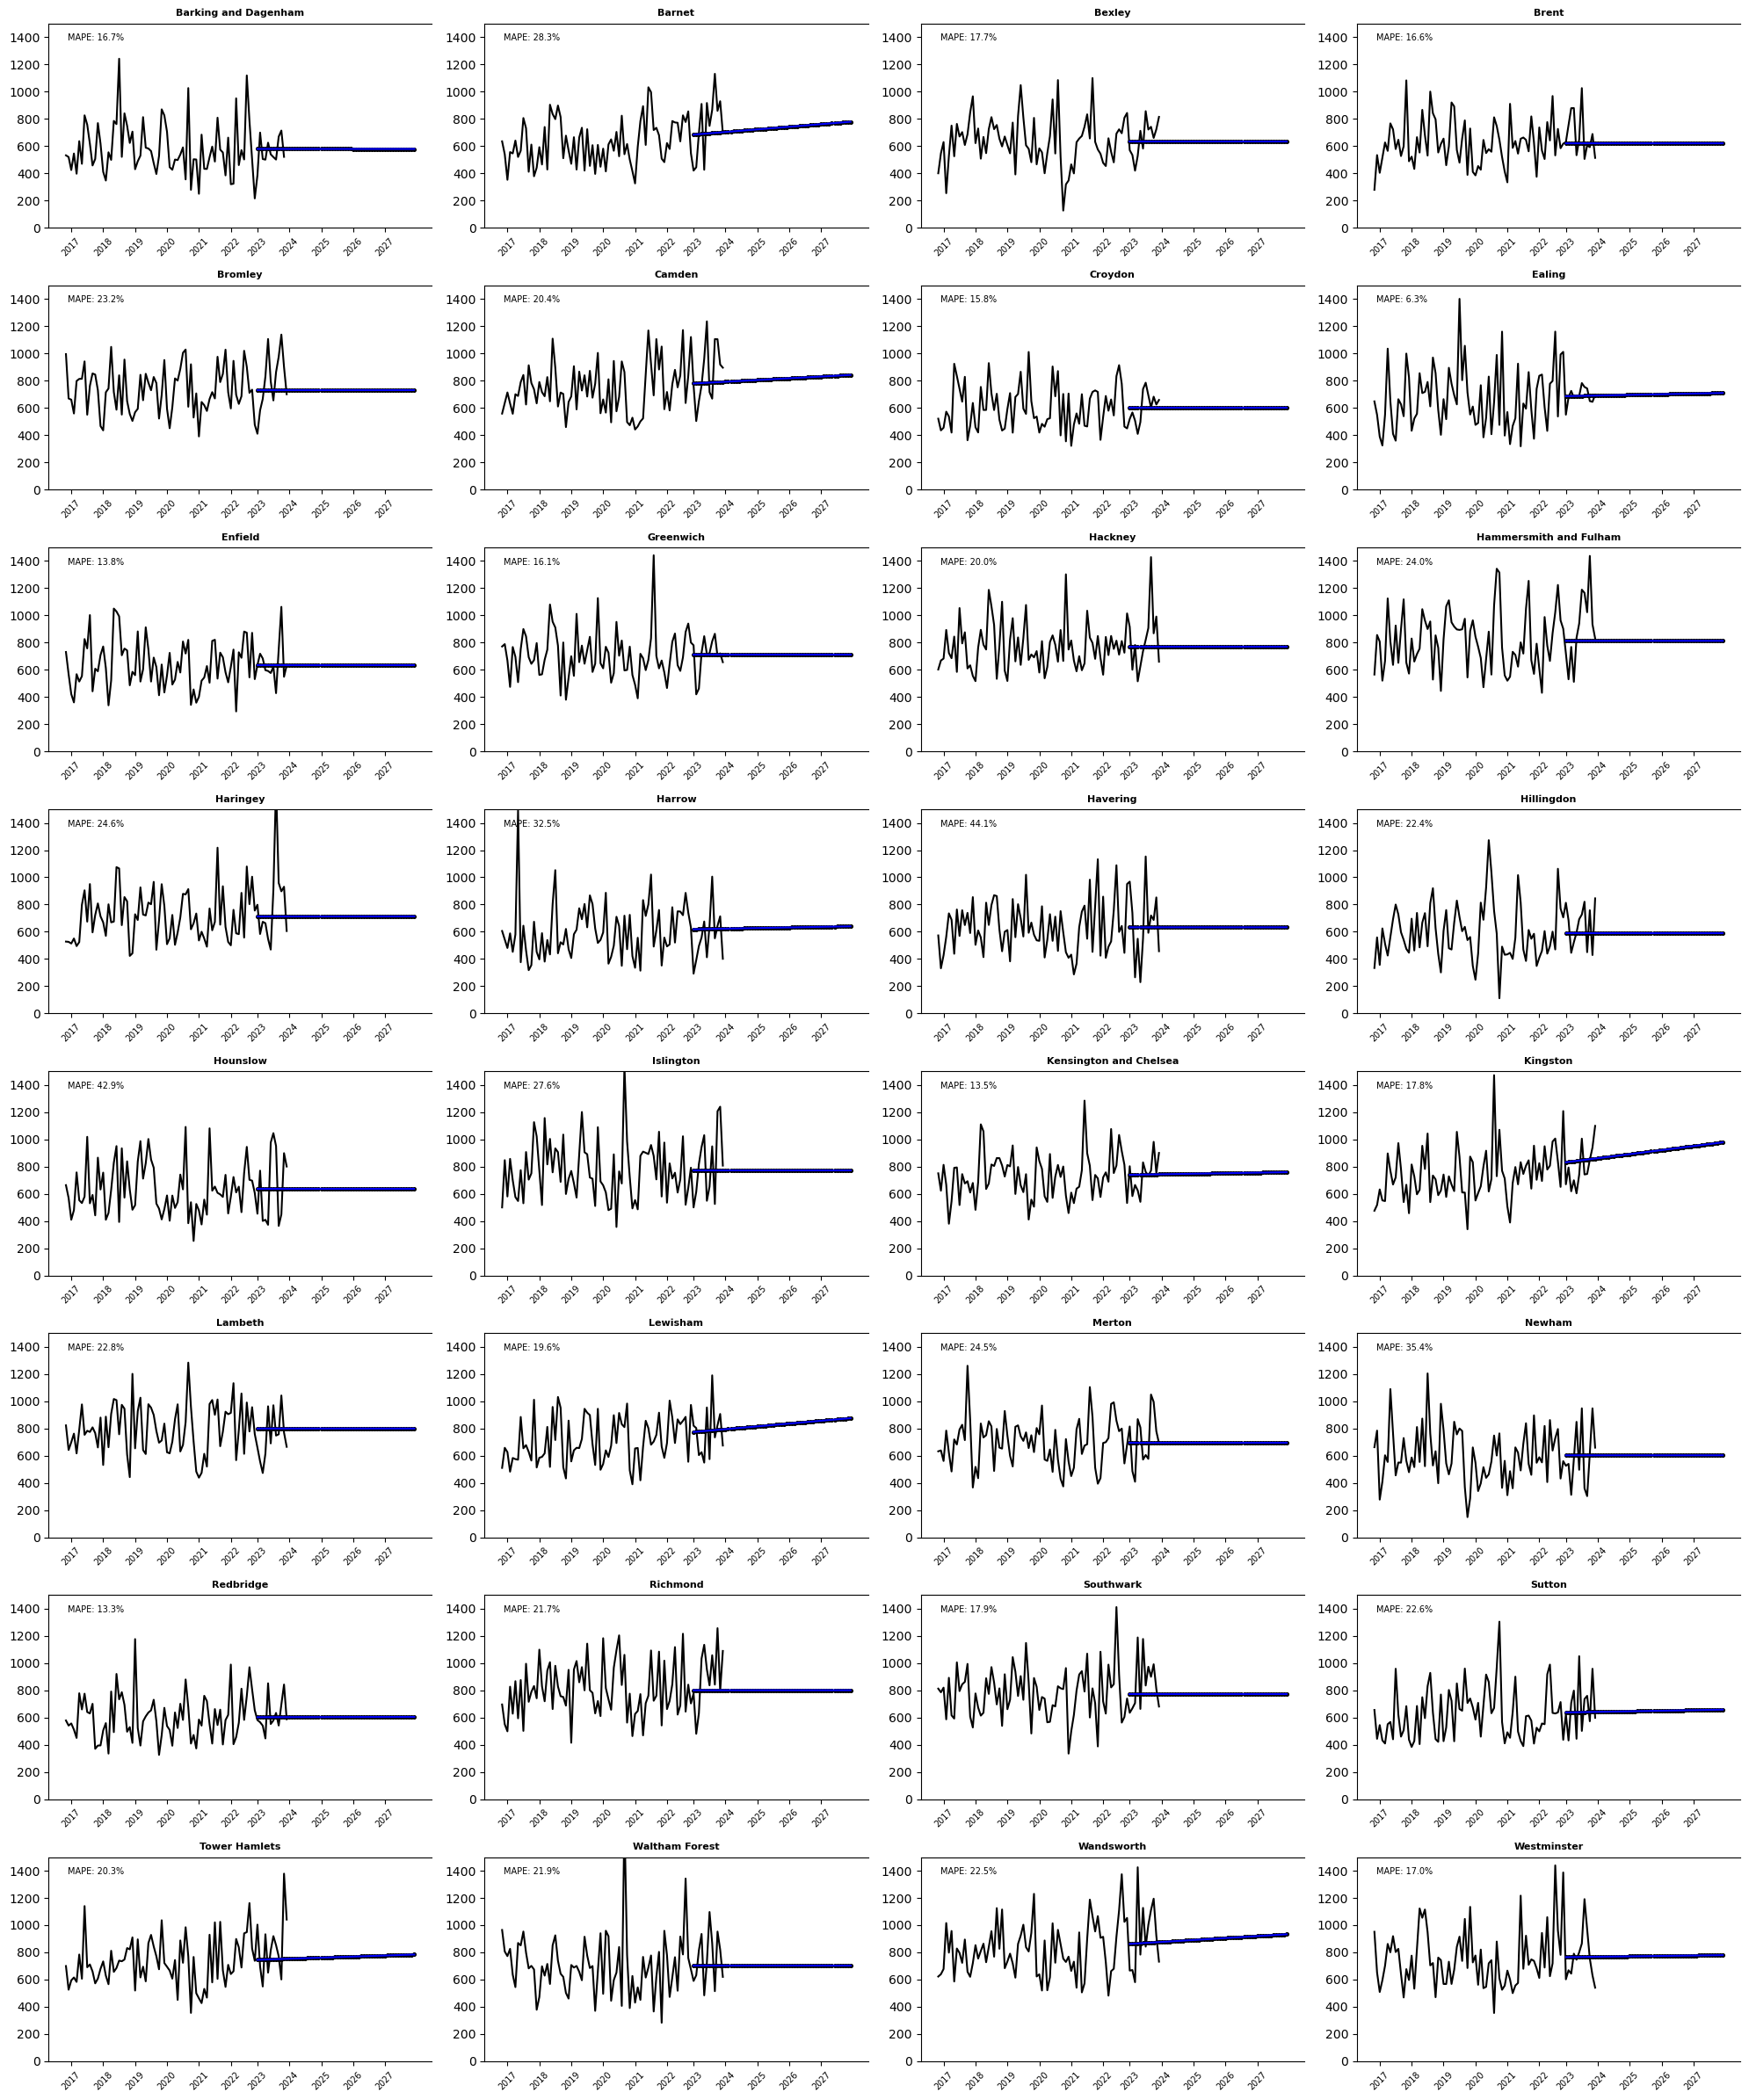

In [8]:
from forecasting_class import Forecast

f = Forecast(df_month, forecast_steps=60, group_col='LA_Name')
f.prophet()
f.bayesian_ridge()
f.sarima()
f.plot(toplot='prophet')
f.plot(toplot='sarima')
f.plot(toplot='bayesian_ridge')

15:15:36 - cmdstanpy - INFO - Chain [1] start processing
15:15:36 - cmdstanpy - INFO - Chain [1] done processing
15:15:36 - cmdstanpy - INFO - Chain [1] start processing
15:15:36 - cmdstanpy - INFO - Chain [1] done processing
15:15:36 - cmdstanpy - INFO - Chain [1] start processing
15:15:36 - cmdstanpy - INFO - Chain [1] done processing
15:15:36 - cmdstanpy - INFO - Chain [1] start processing
15:15:36 - cmdstanpy - INFO - Chain [1] done processing
15:15:36 - cmdstanpy - INFO - Chain [1] start processing
15:15:36 - cmdstanpy - INFO - Chain [1] done processing
15:15:36 - cmdstanpy - INFO - Chain [1] start processing
15:15:36 - cmdstanpy - INFO - Chain [1] done processing
15:15:36 - cmdstanpy - INFO - Chain [1] start processing
15:15:36 - cmdstanpy - INFO - Chain [1] done processing
15:15:36 - cmdstanpy - INFO - Chain [1] start processing
15:15:36 - cmdstanpy - INFO - Chain [1] done processing
15:15:37 - cmdstanpy - INFO - Chain [1] start processing
15:15:37 - cmdstanpy - INFO - Chain [1]

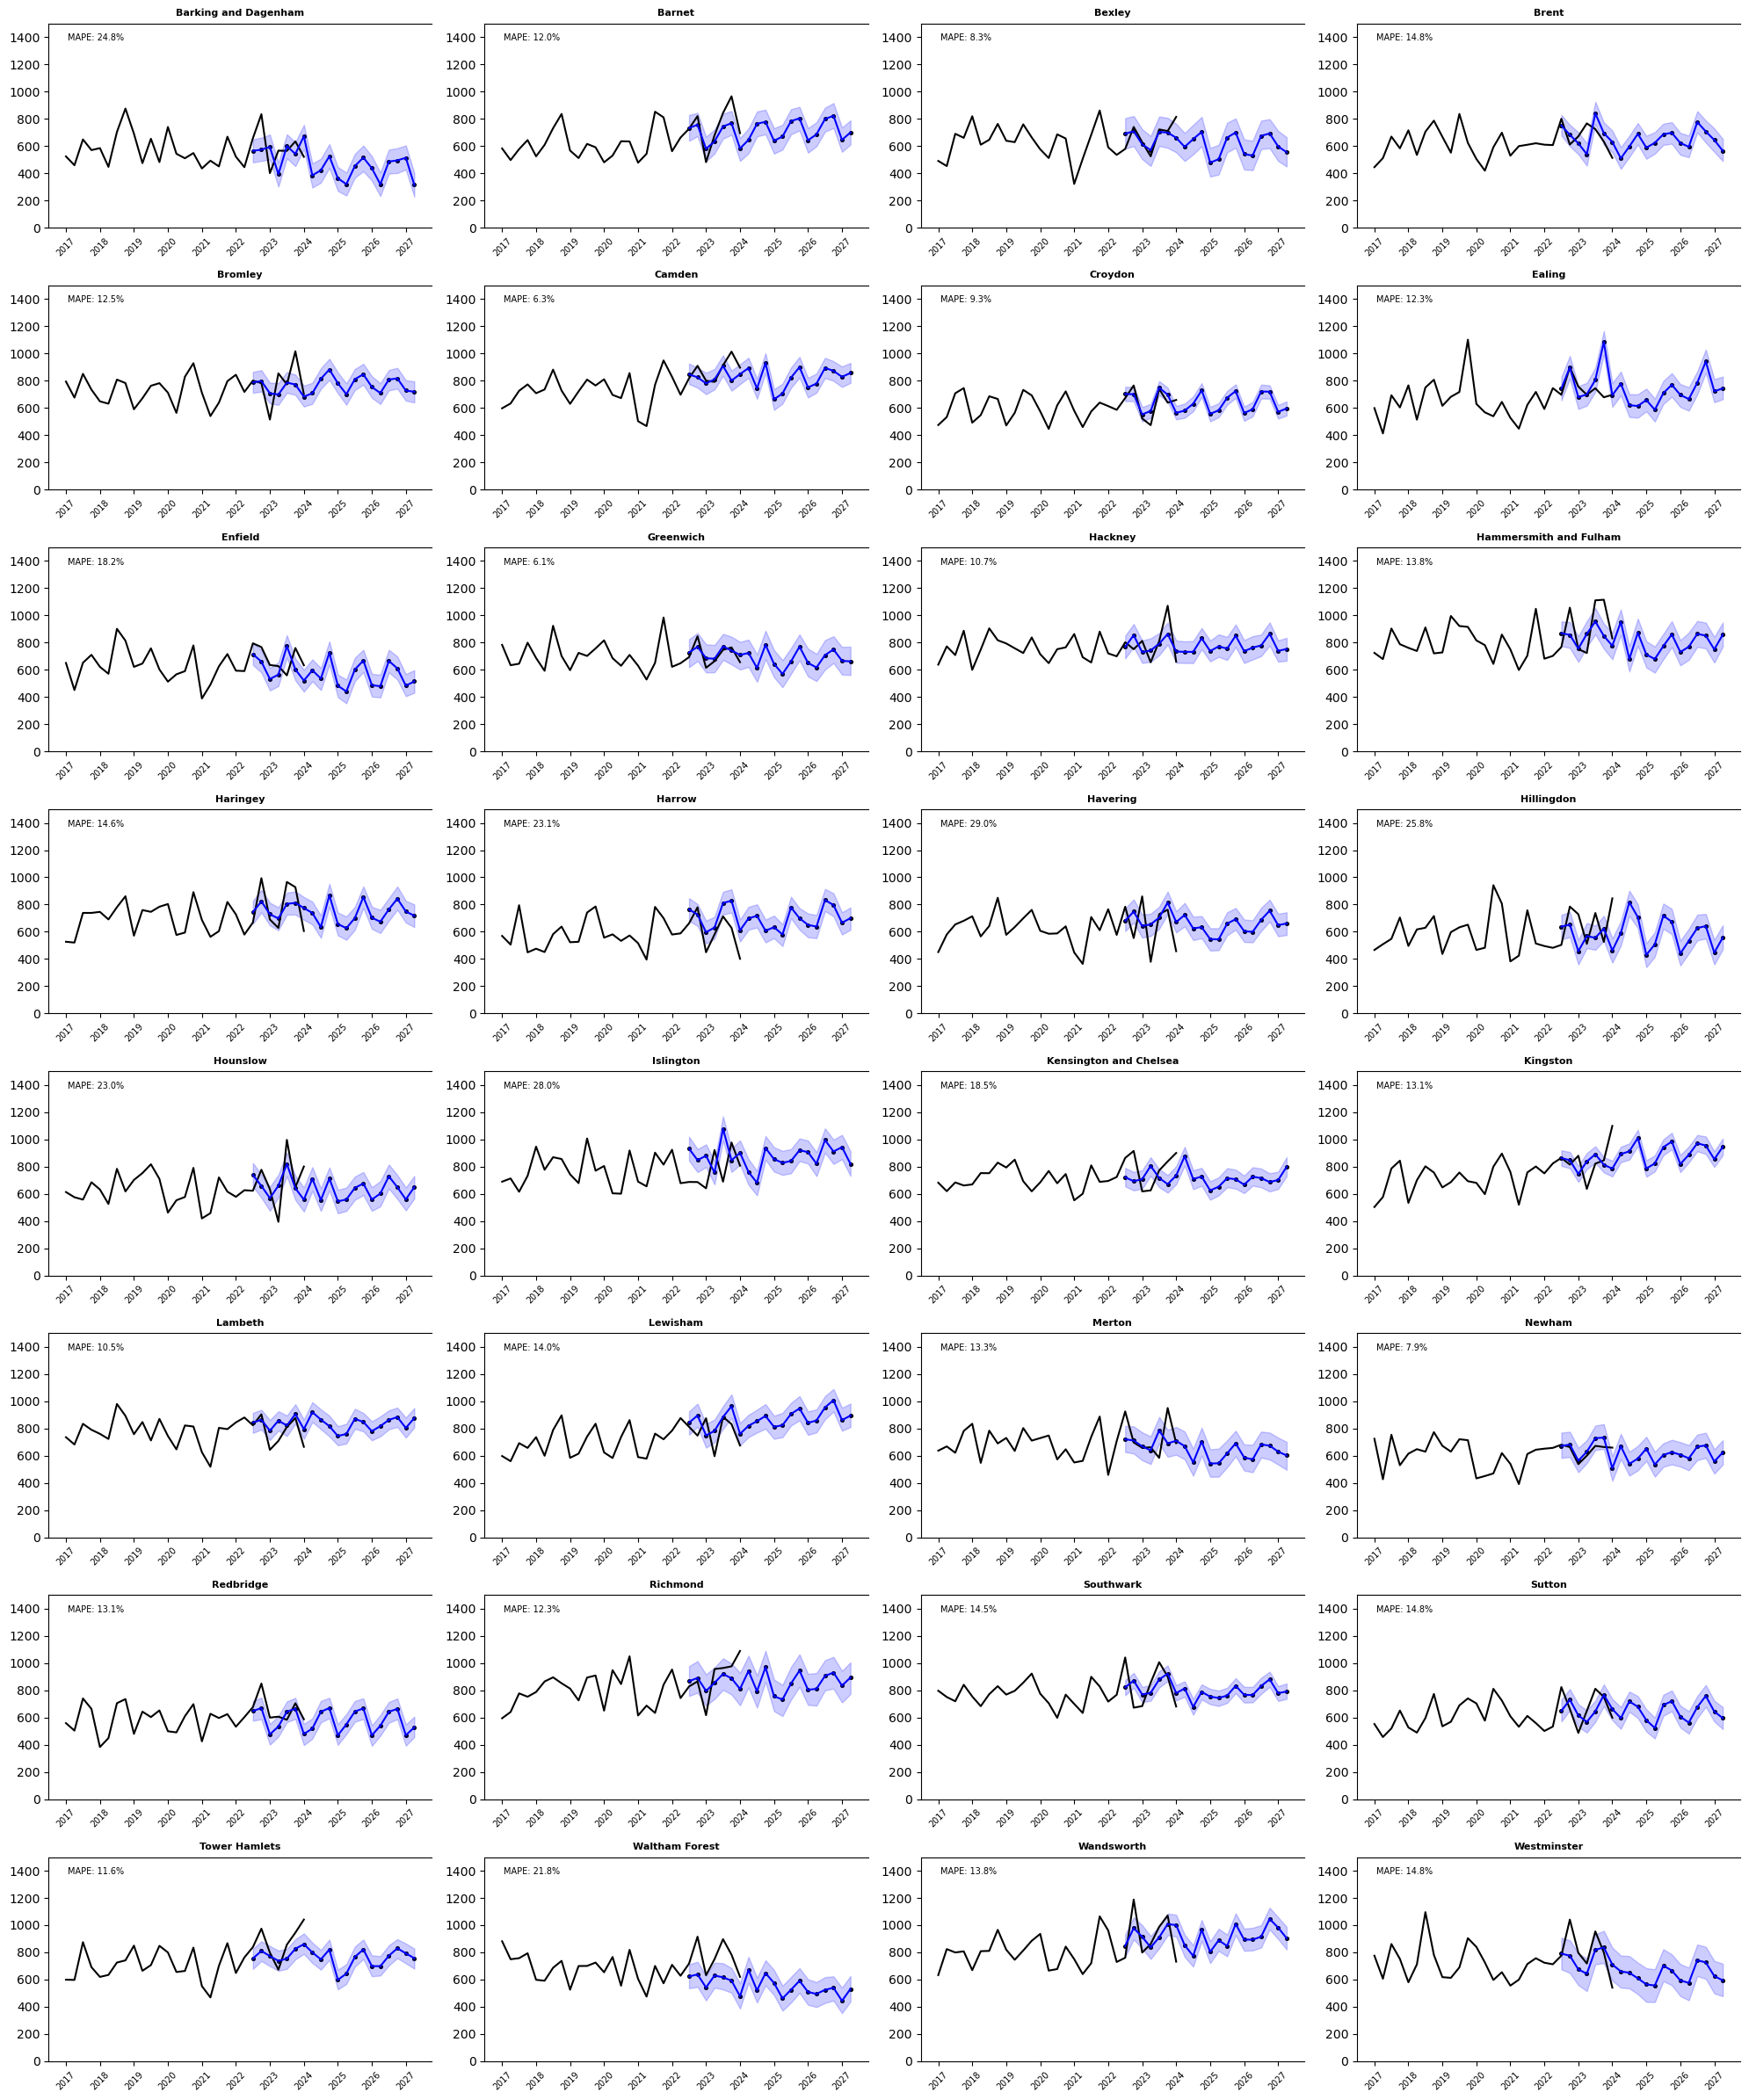

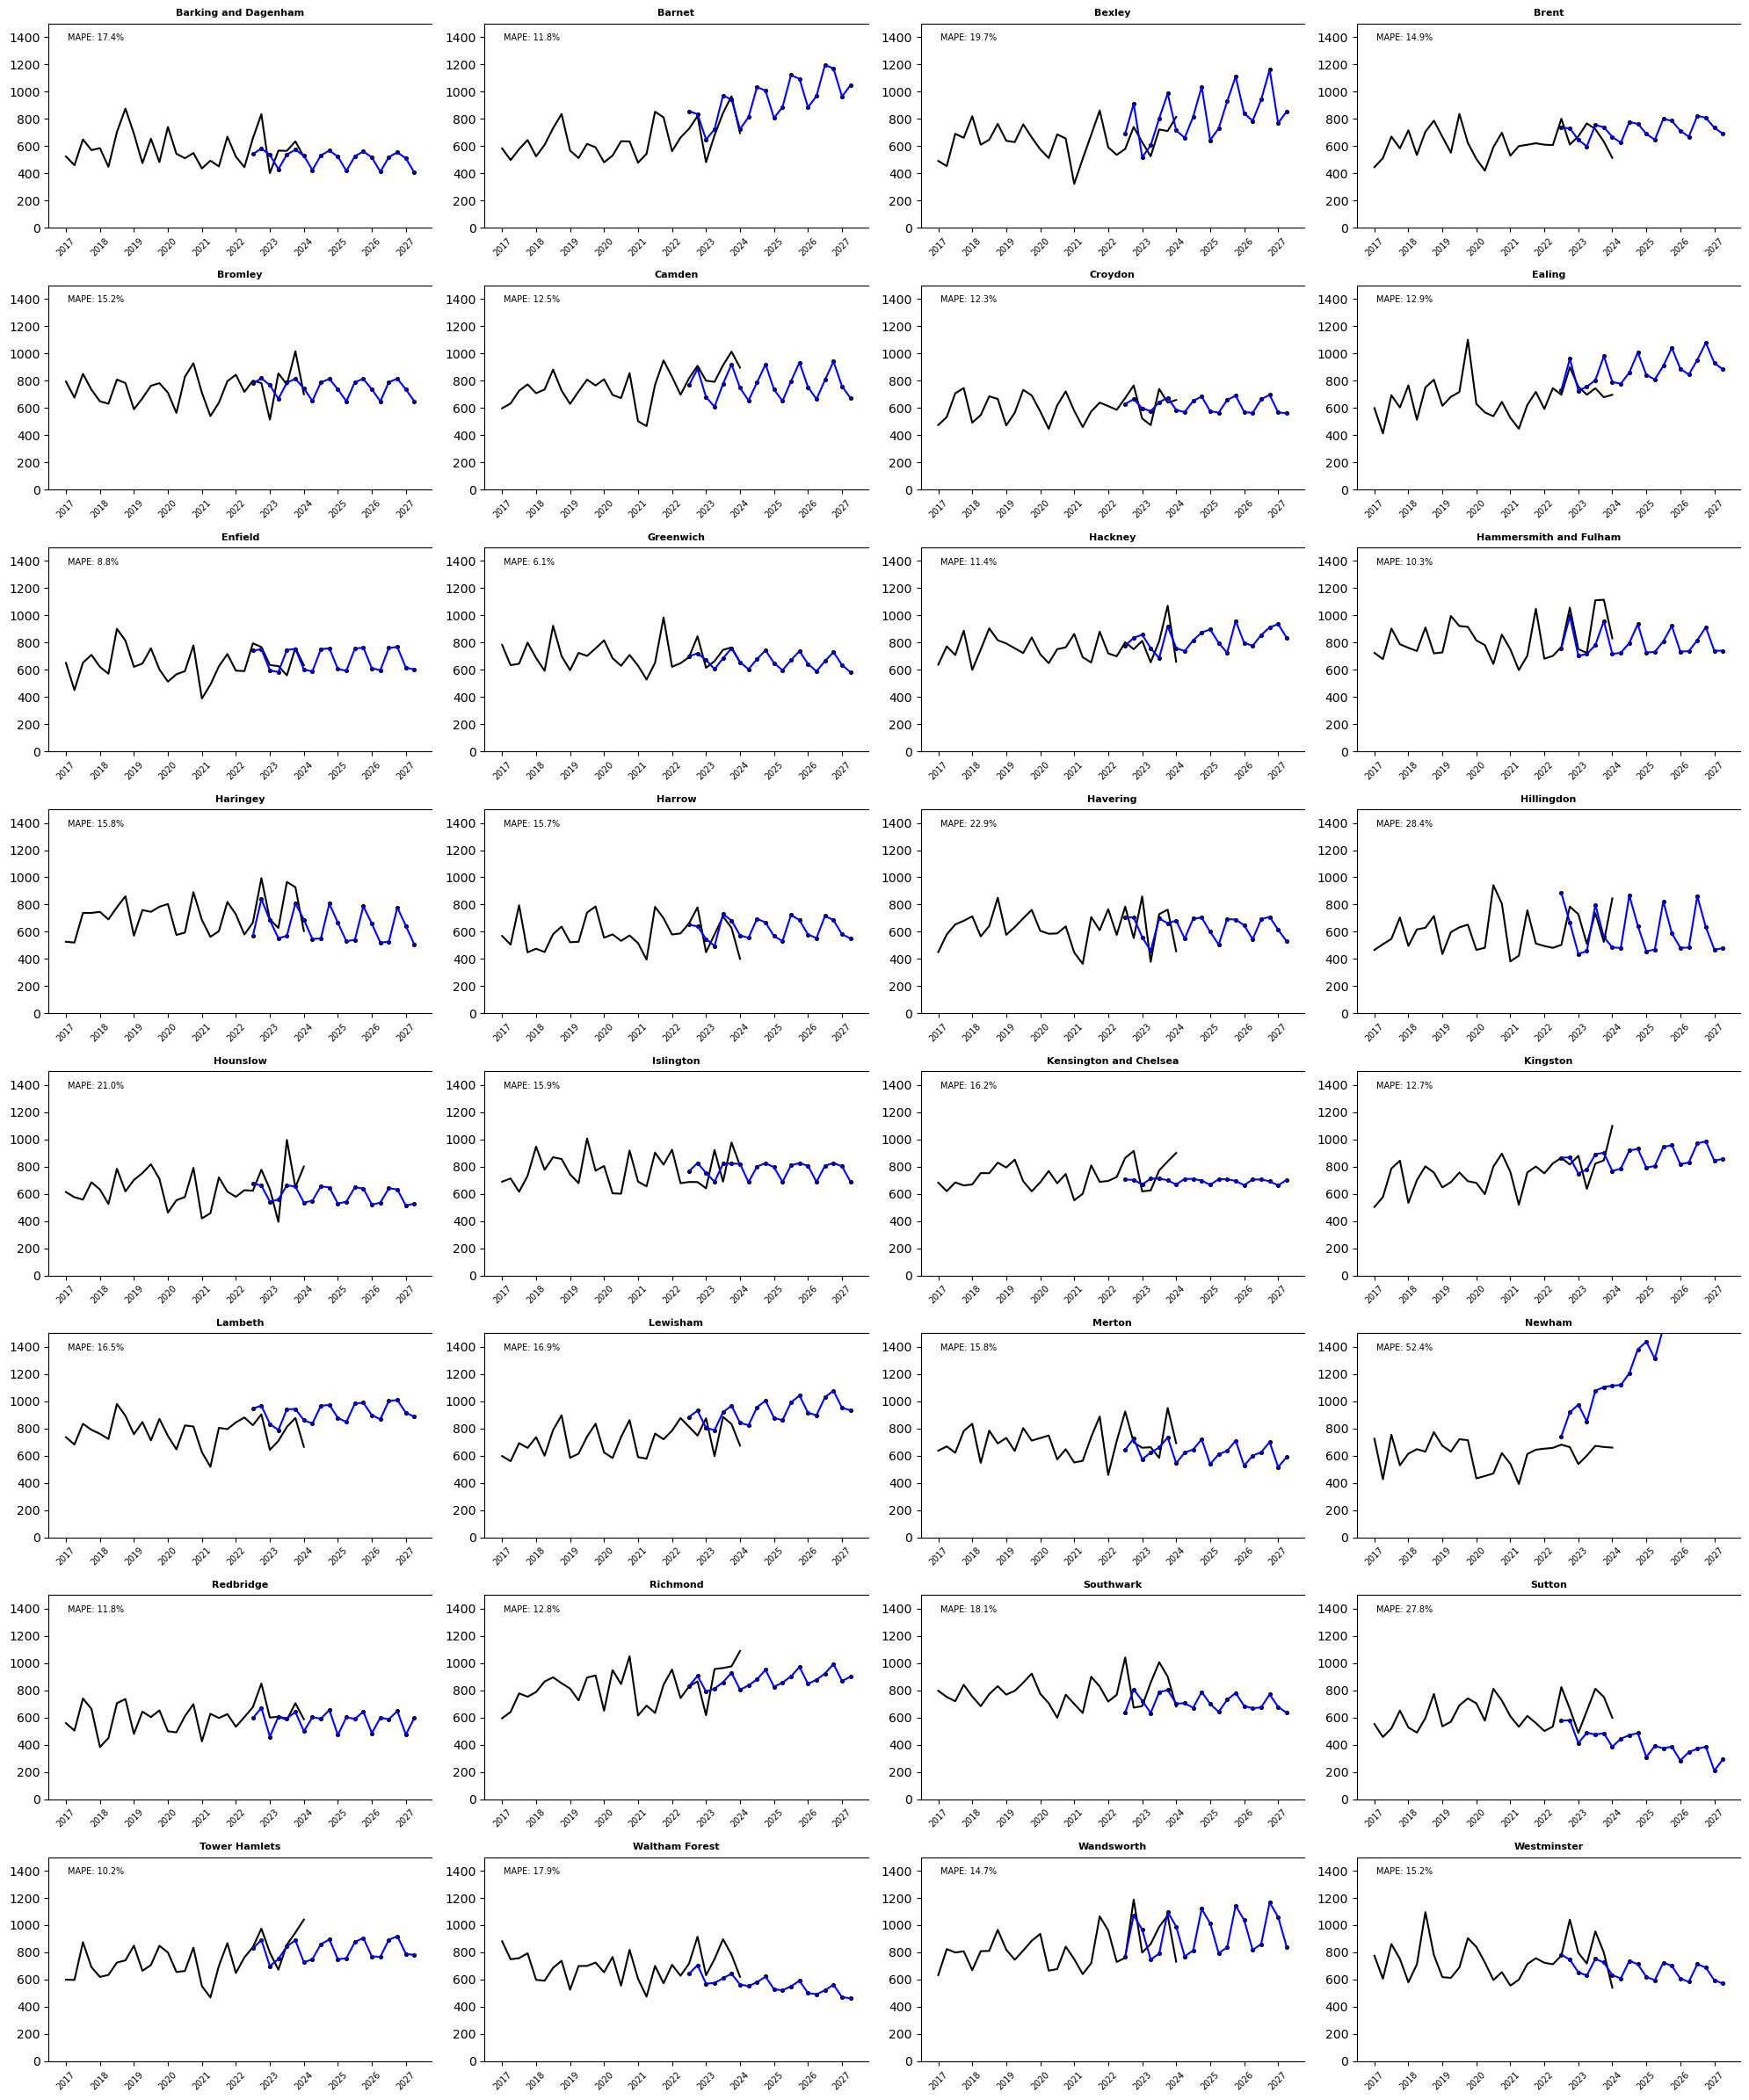

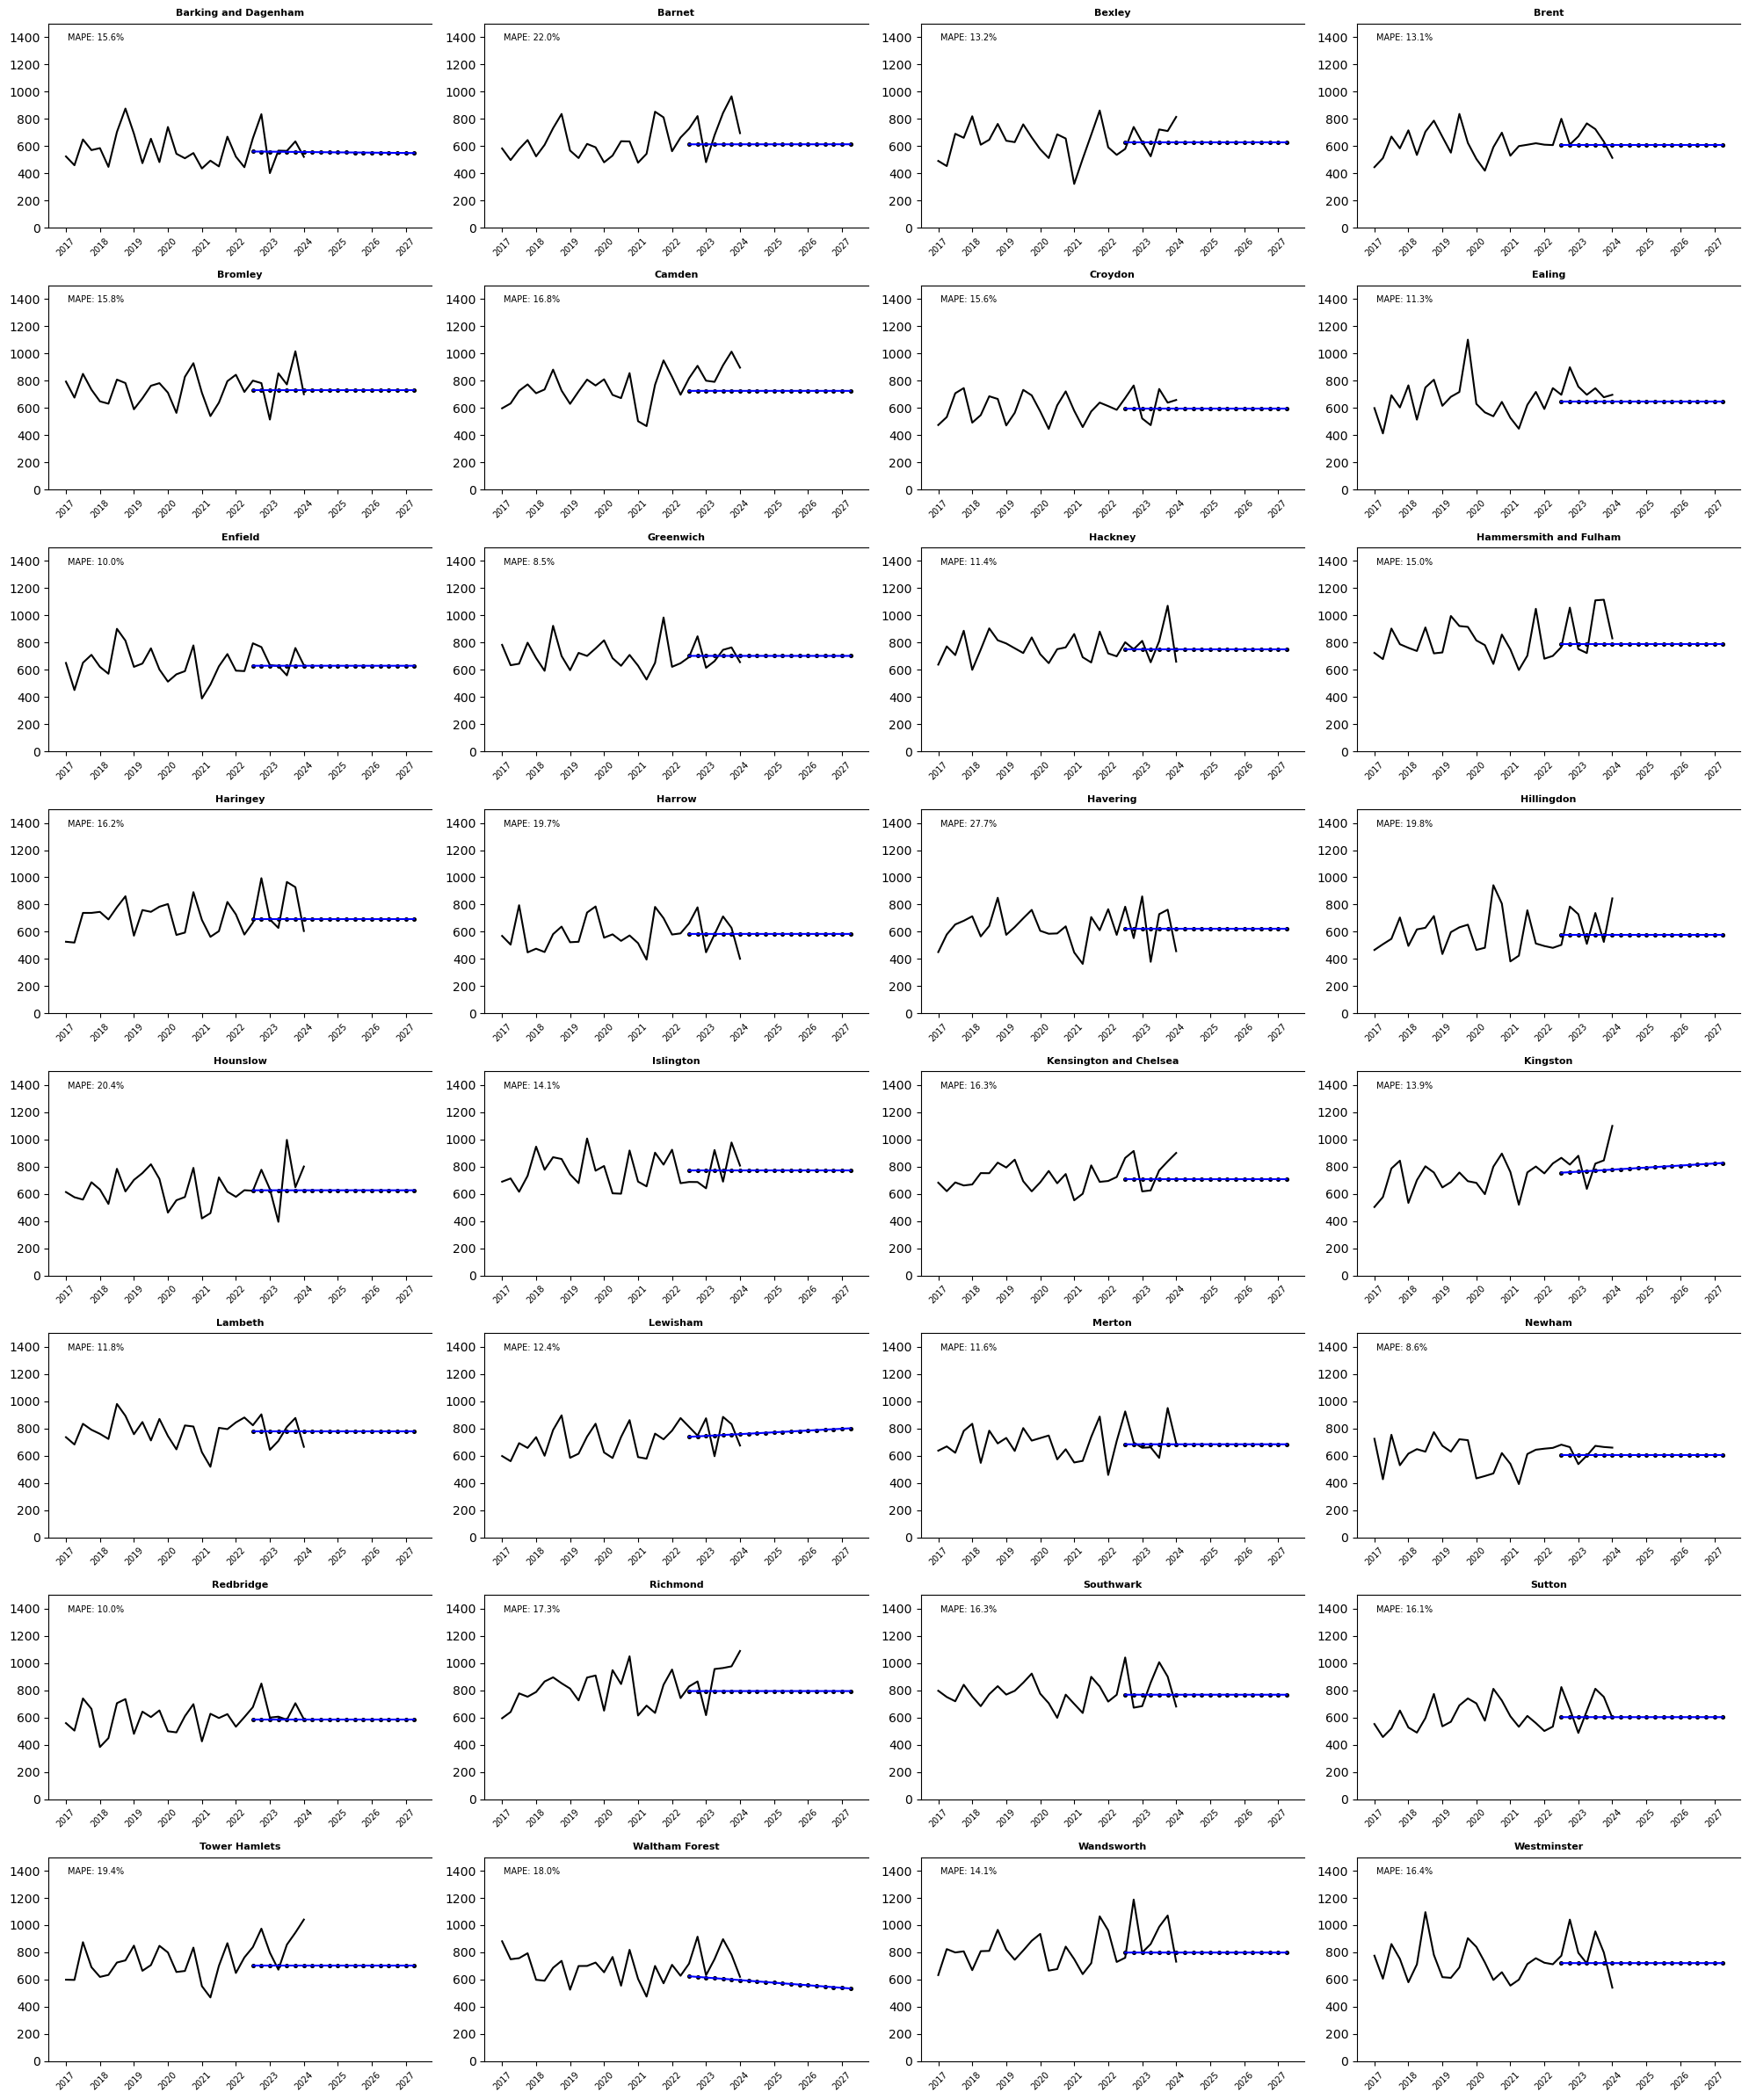

In [9]:
f2 = Forecast(df_quarter, forecast_steps=20, group_col='LA_Name')
f2.prophet()
f2.bayesian_ridge()
f2.sarima()
f2.plot(toplot='prophet')
f2.plot(toplot='sarima')
f2.plot(toplot='bayesian_ridge')

15:15:44 - cmdstanpy - INFO - Chain [1] start processing
15:15:44 - cmdstanpy - INFO - Chain [1] done processing
15:15:44 - cmdstanpy - INFO - Chain [1] start processing
15:15:44 - cmdstanpy - INFO - Chain [1] done processing
15:15:44 - cmdstanpy - INFO - Chain [1] start processing
15:15:44 - cmdstanpy - INFO - Chain [1] done processing
15:15:44 - cmdstanpy - INFO - Chain [1] start processing
15:15:44 - cmdstanpy - INFO - Chain [1] done processing
15:15:44 - cmdstanpy - INFO - Chain [1] start processing
15:15:47 - cmdstanpy - INFO - Chain [1] done processing
15:15:47 - cmdstanpy - INFO - Chain [1] start processing
15:15:50 - cmdstanpy - INFO - Chain [1] done processing
15:15:50 - cmdstanpy - INFO - Chain [1] start processing
15:15:50 - cmdstanpy - INFO - Chain [1] done processing
15:15:50 - cmdstanpy - INFO - Chain [1] start processing
15:15:52 - cmdstanpy - INFO - Chain [1] done processing
15:15:52 - cmdstanpy - INFO - Chain [1] start processing
15:15:52 - cmdstanpy - INFO - Chain [1]

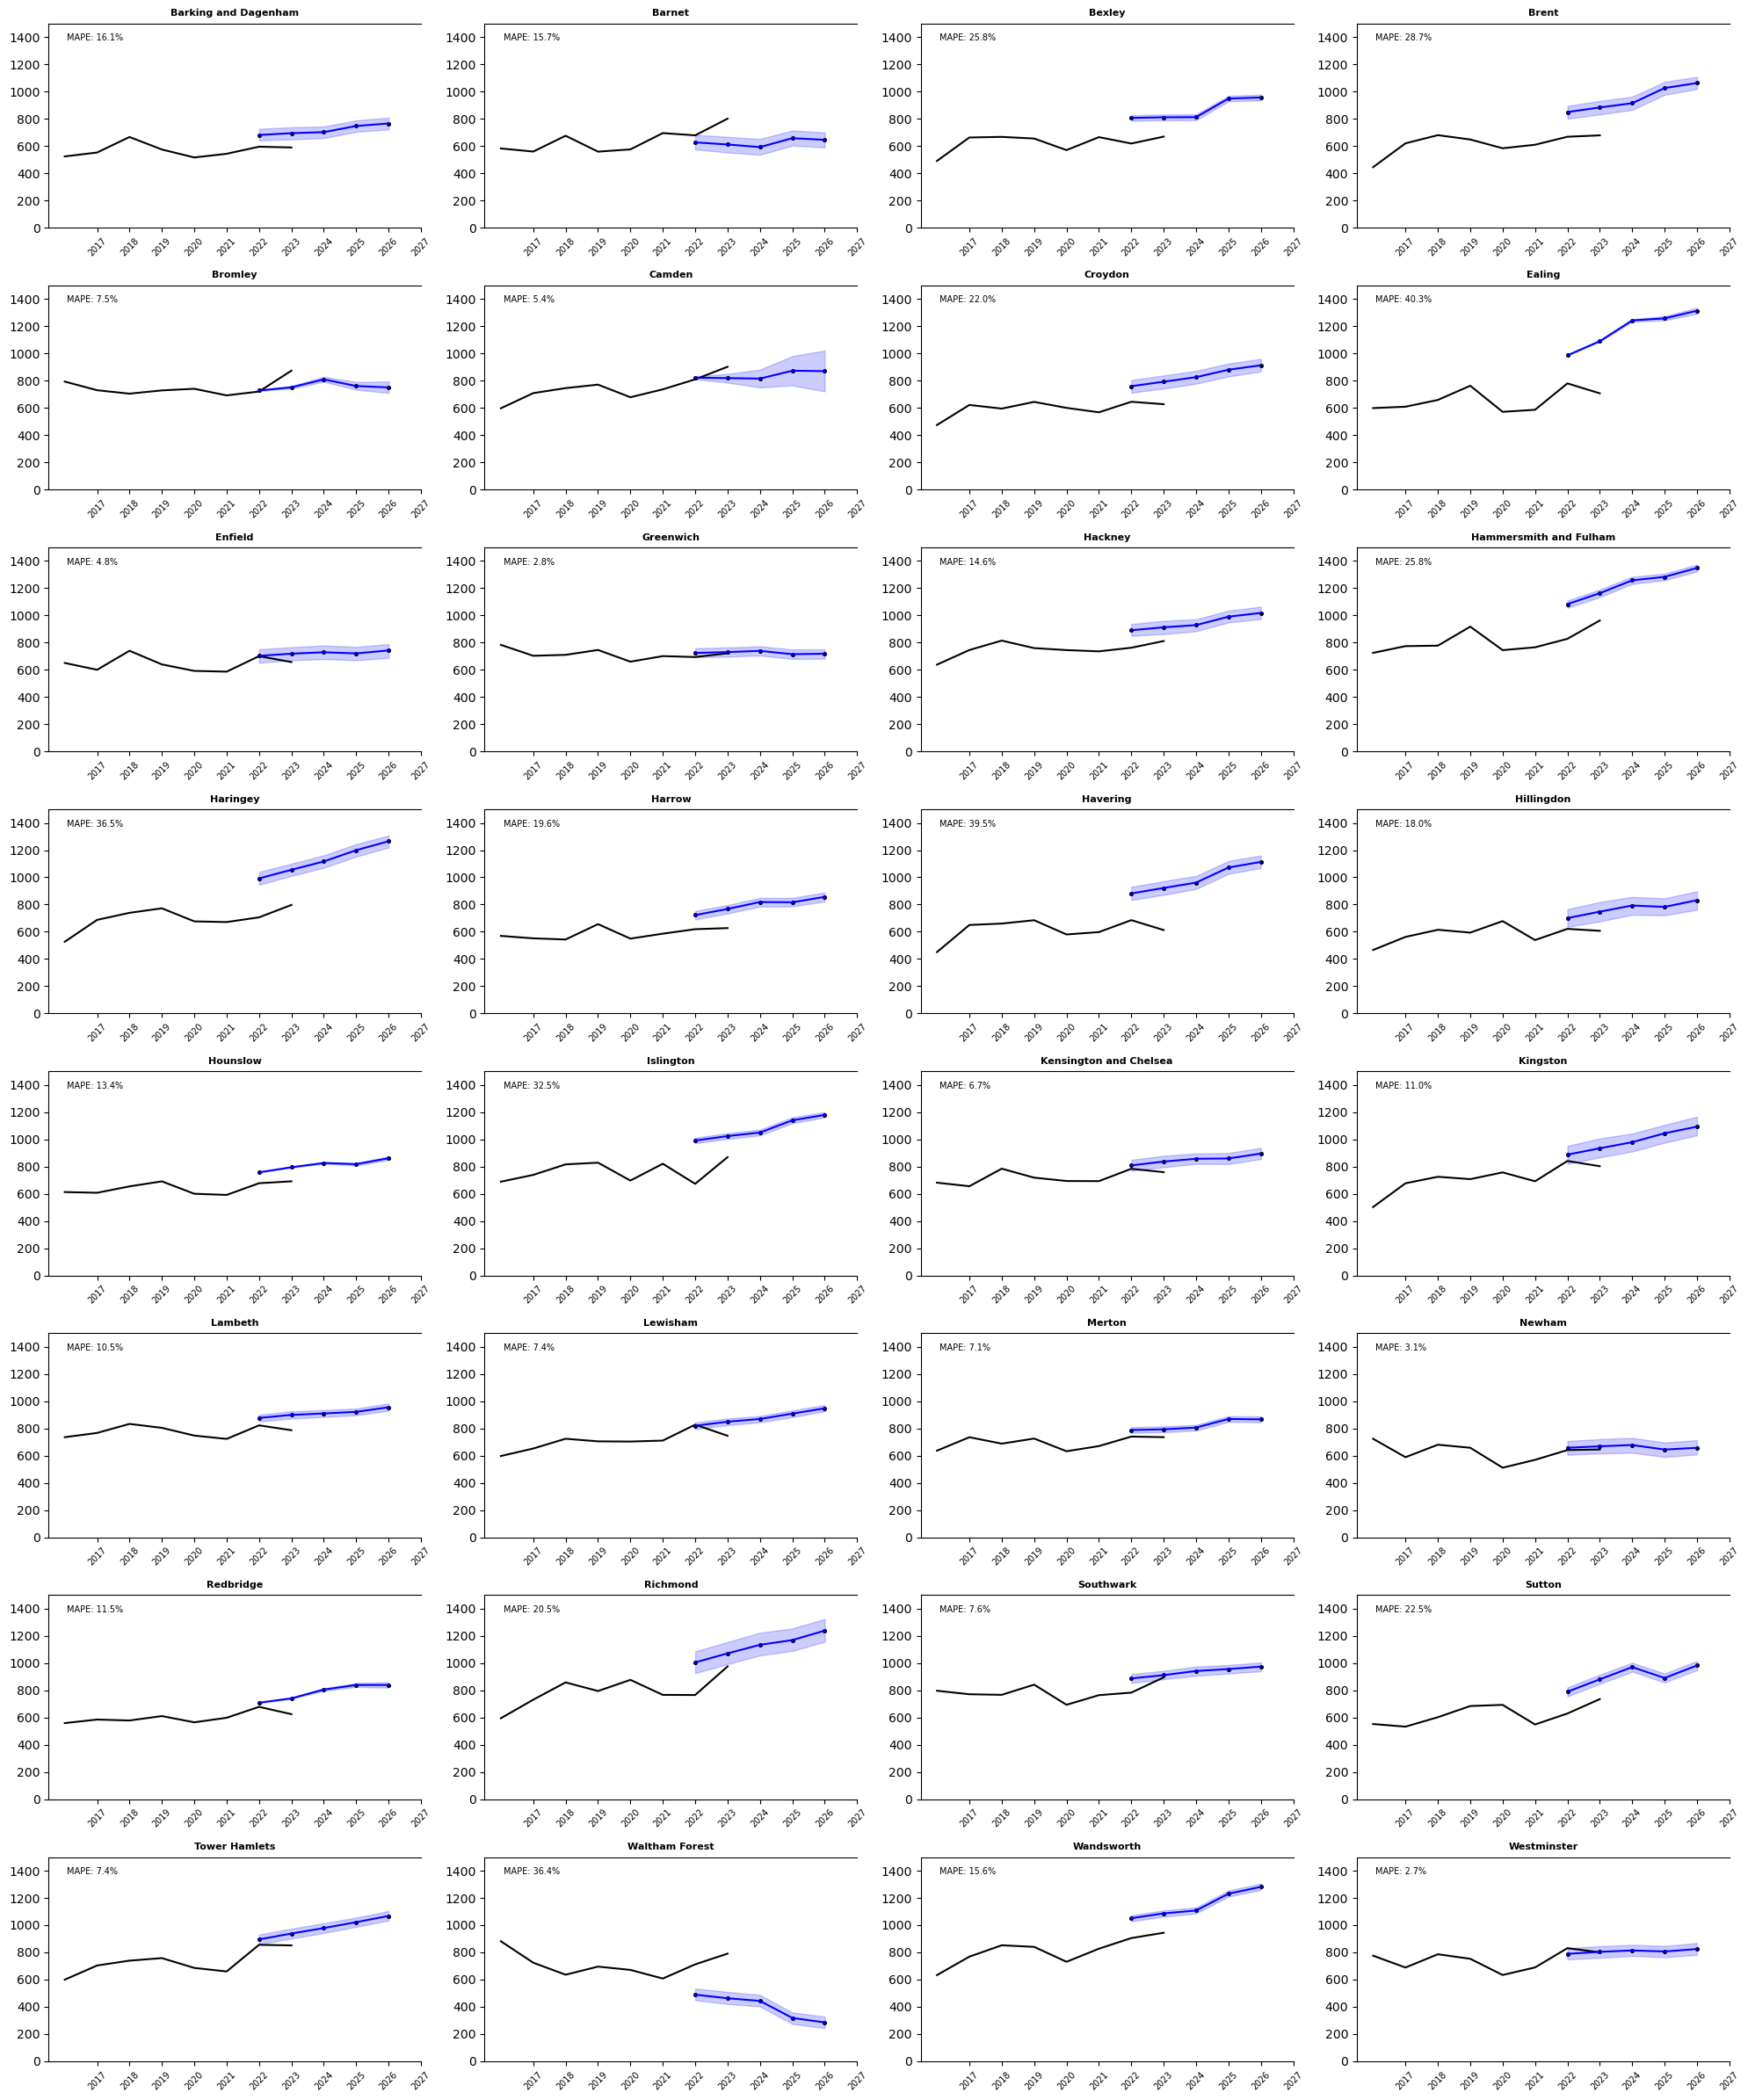

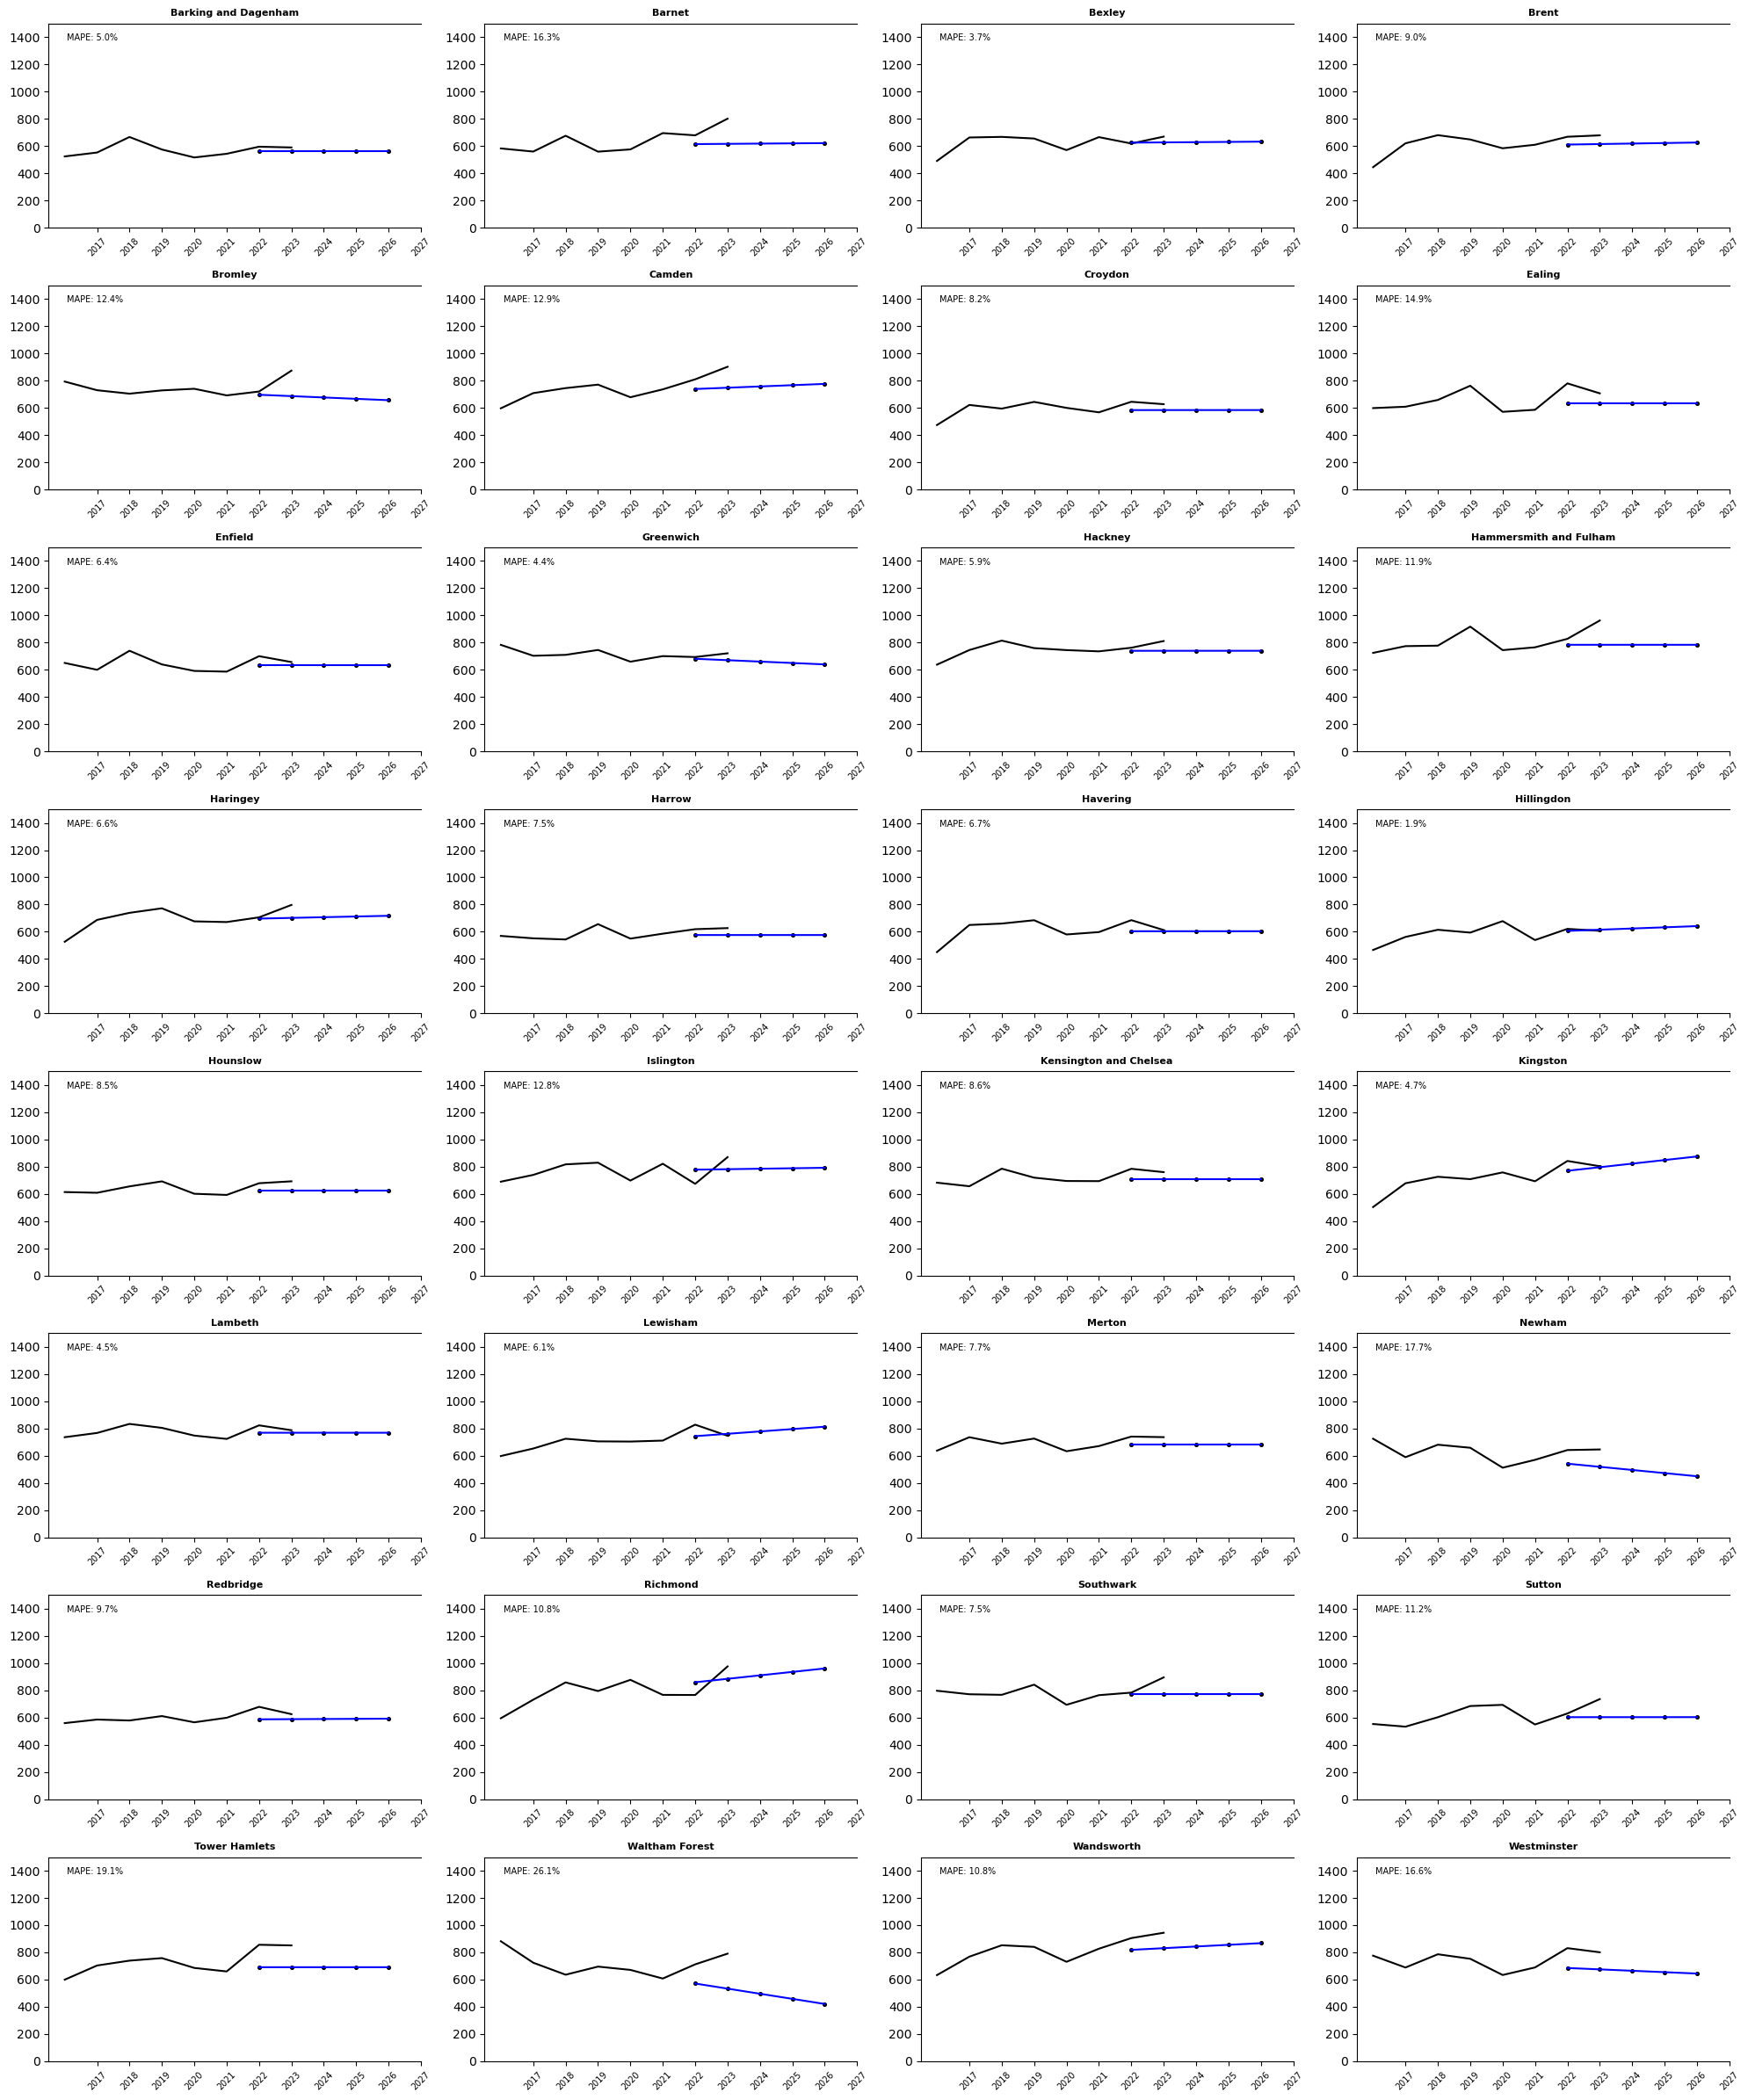

In [10]:
f3 = Forecast(df_year, forecast_steps=5, group_col='LA_Name')
f3.prophet()
f3.bayesian_ridge()
#f3.sarima()
f3.plot(toplot='prophet')
#f3.plot(toplot='sarima')
f3.plot(toplot='bayesian_ridge')

In [11]:
mape_data = {
    'Resolution': ['Monthly', 'Monthly', 'Quarterly', 'Quarterly', 'Yearly', 'Yearly'],
    'Method': ['Prophet', 'SARIMA', 'Prophet', 'SARIMA', 'Prophet', 'BayesianRidge'],
    'MAPE (%)': [
        f.get_mape('prophet'),
        f.get_mape('sarima'),
        f2.get_mape('prophet'),
        f2.get_mape('sarima'),
        f3.get_mape('prophet'),
        f3.get_mape('bayesian_ridge')
    ]
}

df_mape = pd.DataFrame(mape_data)
df_mape['MAPE (%)'] = df_mape['MAPE (%)'].round(2)
print(df_mape.to_string(index=False))

Resolution        Method  MAPE (%)
   Monthly       Prophet     25.00
   Monthly        SARIMA     23.93
 Quarterly       Prophet     15.21
 Quarterly        SARIMA     16.63
    Yearly       Prophet     16.85
    Yearly BayesianRidge      9.88


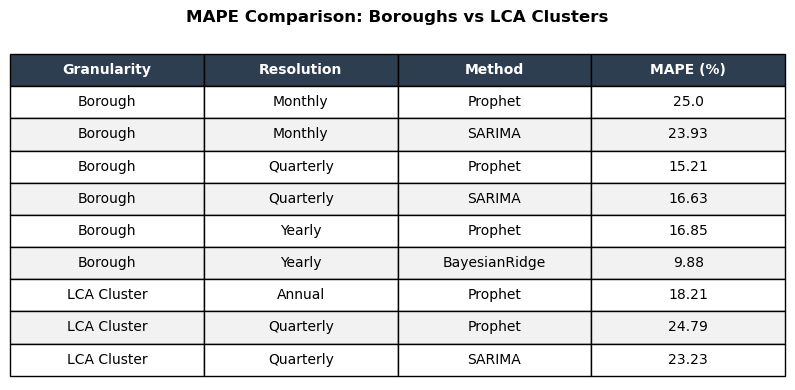

In [12]:
mape_data = {
    'Granularity': ['Borough', 'Borough', 'Borough', 'Borough', 'Borough', 'Borough',
                    'LCA Cluster', 'LCA Cluster', 'LCA Cluster'],
    'Resolution': ['Monthly', 'Monthly', 'Quarterly', 'Quarterly', 'Yearly', 'Yearly',
                   'Annual', 'Quarterly', 'Quarterly'],
    'Method': ['Prophet', 'SARIMA', 'Prophet', 'SARIMA', 'Prophet', 'BayesianRidge',
               'Prophet', 'Prophet', 'SARIMA'],
    'MAPE (%)': [25.00, 23.93, 15.21, 16.63, 16.85, 9.88,
                 18.21, 24.79, 23.23]
}

df_mape = pd.DataFrame(mape_data)

fig, ax = plt.subplots(figsize=(8, 4))
ax.axis('off')
table = ax.table(
    cellText=df_mape.values,
    colLabels=df_mape.columns,
    cellLoc='center',
    loc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.8)

# Header styling
for j in range(len(df_mape.columns)):
    table[0, j].set_facecolor('#2c3e50')
    table[0, j].set_text_props(color='white', fontweight='bold')

# Alternate row colours
for i in range(1, len(df_mape) + 1):
    for j in range(len(df_mape.columns)):
        table[i, j].set_facecolor('#f2f2f2' if i % 2 == 0 else 'white')

plt.title('MAPE Comparison: Boroughs vs LCA Clusters', fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('mape_table.png', dpi=150, bbox_inches='tight')
plt.show()

# SARIMA was tested at monthly and quarterly where autocorrelation structure is richest — at yearly level there are only 6 data points, making SARIMA unreliable.
# BayesianRidge was used for yearly only — with just 6 annual observations it outperforms SARIMA (9.88% vs unstable), using regularisation to avoid overfitting on small samples.
# Prophet was tested at all resolutions as it's designed for seasonal time series and handles the COVID disruption via holiday regress

In [13]:
from pathlib import Path
ROOT = Path('/Users/josh/Library/CloudStorage/GoogleDrive-jeverer@gmail.com/My Drive/London Sport/london_sport2')
list(ROOT.rglob('*.shp'))

[]

In [14]:
import geopandas

In [15]:
import geopandas as gpd

url = "https://raw.githubusercontent.com/radoi90/housequest-data/master/london_boroughs.geojson"
gdf = gpd.read_file(url)
print(gdf.columns.tolist())

['name', 'color', 'geometry']


In [16]:
print(sorted(gdf['name'].tolist()))

['Barking and Dagenham', 'Barnet', 'Bexley', 'Brent', 'Bromley', 'Camden', 'City of London', 'Croydon', 'Ealing', 'Enfield', 'Greenwich', 'Hackney', 'Hammersmith and Fulham', 'Haringey', 'Harrow', 'Havering', 'Hillingdon', 'Hounslow', 'Islington', 'Kensington and Chelsea', 'Kingston upon Thames', 'Lambeth', 'Lewisham', 'Merton', 'Newham', 'Redbridge', 'Richmond upon Thames', 'Southwark', 'Sutton', 'Tower Hamlets', 'Waltham Forest', 'Wandsworth', 'Westminster']


In [17]:
summer = df_month[df_month['month'].isin([6,7,8])].groupby('LA_Name')['MEMS7_ALL'].mean()
winter = df_month[df_month['month'].isin([12,1,2])].groupby('LA_Name')['MEMS7_ALL'].mean()
amplitude = (summer - winter).reset_index()
amplitude.columns = ['LA_Name', 'amplitude']

amplitude['LA_Name'] = amplitude['LA_Name'].replace({
    'Kingston': 'Kingston upon Thames',
    'Richmond': 'Richmond upon Thames'
})

gdf_merged = gdf.merge(amplitude, left_on='name', right_on='LA_Name', how='left')
print(gdf_merged[['name', 'amplitude']])

                      name   amplitude
0     Barking and Dagenham  125.507669
1                   Barnet  236.485819
2                   Bexley  216.936147
3                    Brent   94.344696
4                  Bromley  201.049916
5                   Camden  208.946126
6           City of London         NaN
7                  Croydon  204.118174
8                   Ealing  116.767891
9                  Enfield  177.944888
10               Greenwich  233.188501
11                 Hackney  197.716330
12  Hammersmith and Fulham  243.712701
13                Haringey  286.045457
14                  Harrow  181.412530
15                Havering  187.158713
16              Hillingdon  250.873828
17                Hounslow  203.854543
18               Islington   86.656496
19  Kensington and Chelsea  110.712492
20    Kingston upon Thames  192.268186
21                 Lambeth  125.420243
22                Lewisham  210.812801
23                  Merton  134.560257
24                  Newha

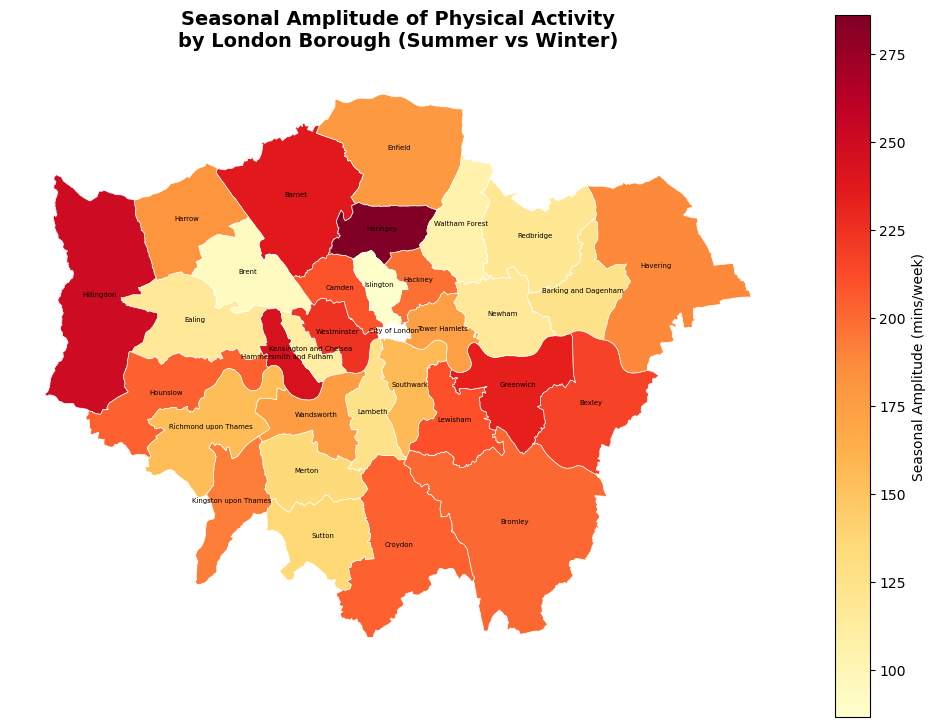

In [18]:
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib import cm

fig, ax = plt.subplots(figsize=(10, 12))

gdf_merged.plot(
    column='amplitude',
    ax=ax,
    cmap='YlOrRd',
    legend=True,
    legend_kwds={'label': 'Seasonal Amplitude (mins/week)', 'shrink': 0.6},
    edgecolor='white',
    linewidth=0.5
)

for _, row in gdf_merged.iterrows():
    ax.annotate(
        row['name'],
        xy=(row.geometry.centroid.x, row.geometry.centroid.y),
        ha='center', fontsize=5, color='black'
    )

ax.set_title('Seasonal Amplitude of Physical Activity\nby London Borough (Summer vs Winter)', 
             fontsize=14, fontweight='bold', pad=15)
ax.axis('off')
plt.tight_layout()
plt.savefig('choropleth_amplitude.png', dpi=150, bbox_inches='tight')
plt.show()

In [19]:
print(f2.sarima_forecast.keys())

Index(['LA_Name', 'y_train', 'y_test', 'y_forecast', 'mape'], dtype='str')


In [20]:
borough_mapes = f2.sarima_forecast[['LA_Name', 'mape']].sort_values('mape')

best_3 = borough_mapes.head(3)['LA_Name'].tolist()
worst_3 = borough_mapes.tail(3)['LA_Name'].tolist()
print("Best:", best_3)
print("Worst:", worst_3)

Best: ['Greenwich', 'Enfield', 'Tower Hamlets']
Worst: ['Sutton', 'Hillingdon', 'Newham']


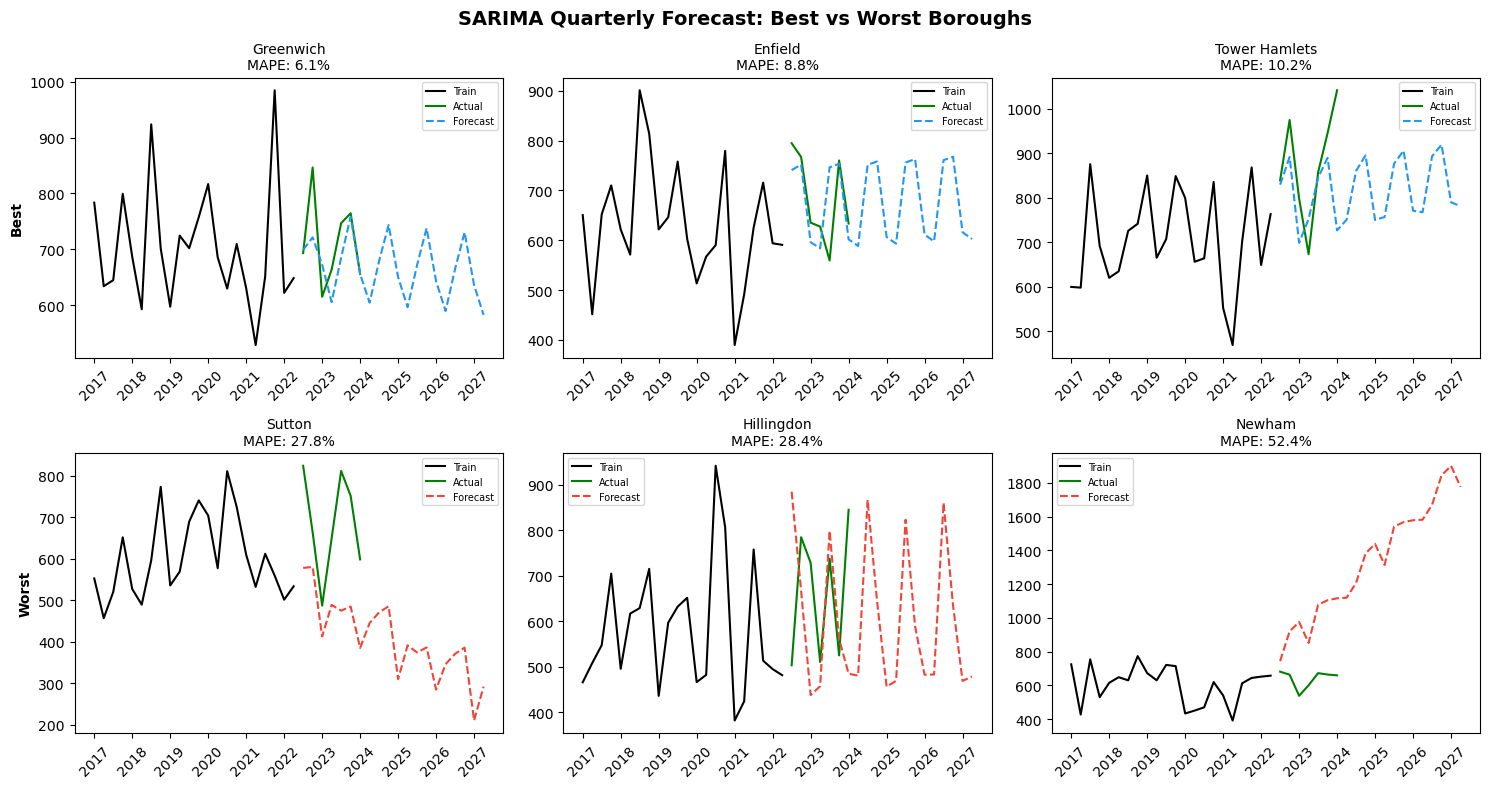

In [21]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('SARIMA Quarterly Forecast: Best vs Worst Boroughs', fontweight='bold', fontsize=14)

for i, (boroughs, label, color) in enumerate([
    (best_3, 'Best', '#2196F3'),
    (worst_3, 'Worst', '#F44336')
]):
    for j, borough in enumerate(boroughs):
        ax = axes[i, j]
        row = f2.sarima_forecast[f2.sarima_forecast['LA_Name'] == borough].iloc[0]
        
        y_train = row['y_train']
        y_test = row['y_test']
        y_forecast = row['y_forecast']
        mape = row['mape']
        
        t_train = list(range(len(y_train)))
        t_test = list(range(len(y_train), len(y_train) + len(y_test)))
        t_forecast = list(range(len(y_train), len(y_train) + len(y_forecast)))
        
        ax.plot(t_train, y_train, color='black', label='Train')
        ax.plot(t_test, y_test, color='green', label='Actual')
        ax.plot(t_forecast, y_forecast, color=color, linestyle='--', label='Forecast')
        ax.set_title(f'{borough}\nMAPE: {mape:.1f}%', fontsize=10)
        ax.set_xticks(f2.ticks)
        ax.set_xticklabels(f2.labels, rotation=45)
        ax.legend(fontsize=7)
        
        if j == 0:
            ax.set_ylabel('Best' if i == 0 else 'Worst', fontweight='bold')

plt.tight_layout()
plt.savefig('best_worst_sarima.png', dpi=150, bbox_inches='tight')
plt.show()

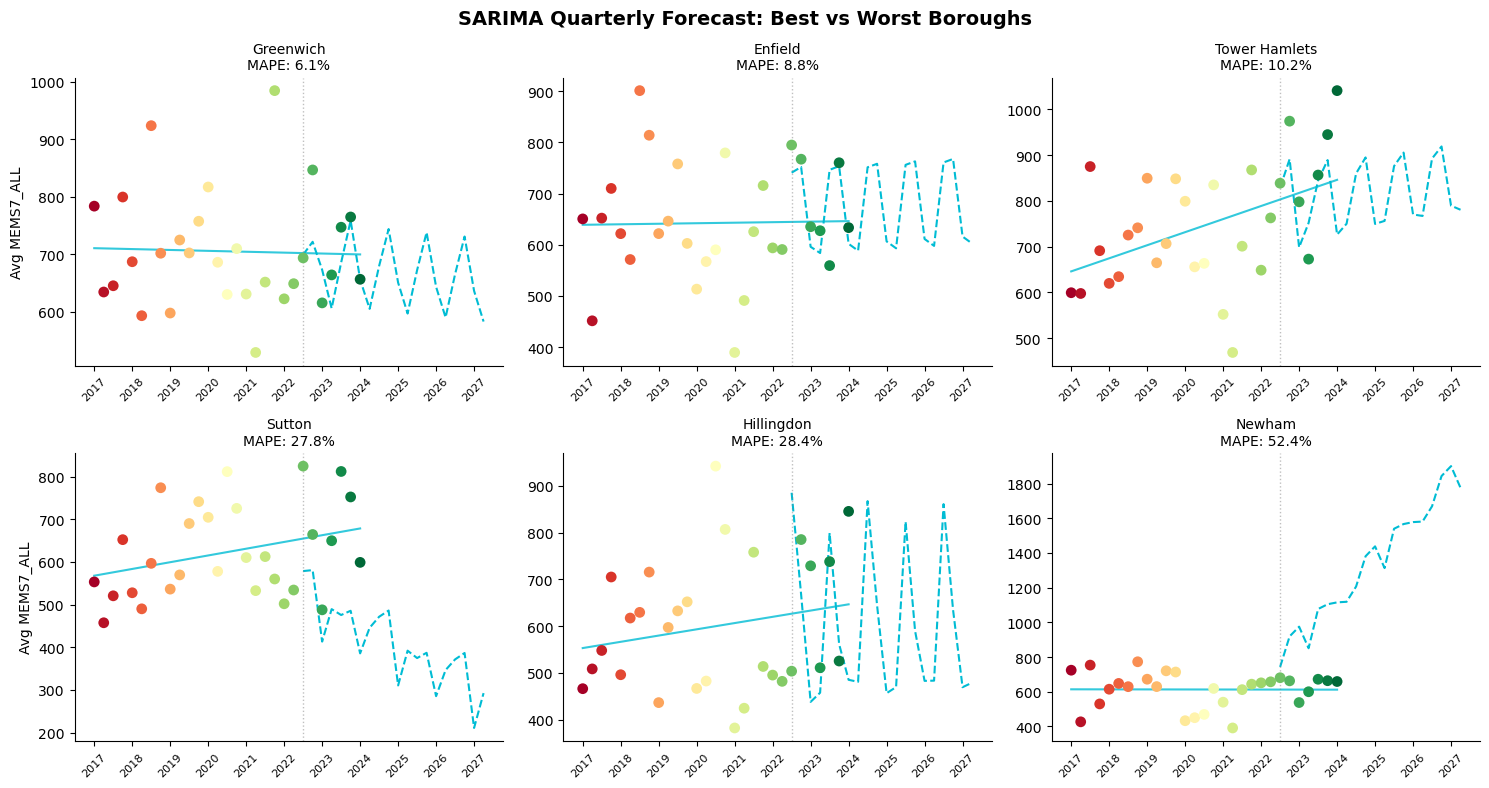

In [22]:
import matplotlib.cm as cm
import numpy as np

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('SARIMA Quarterly Forecast: Best vs Worst Boroughs', fontweight='bold', fontsize=14)

for i, (boroughs, label) in enumerate([(best_3, 'Best'), (worst_3, 'Worst')]):
    for j, borough in enumerate(boroughs):
        ax = axes[i, j]
        row = f2.sarima_forecast[f2.sarima_forecast['LA_Name'] == borough].iloc[0]
        
        y_train = np.array(row['y_train'])
        y_test = np.array(row['y_test'])
        y_forecast = np.array(row['y_forecast'])
        mape = row['mape']
        
        y_actual = np.concatenate([y_train, y_test])
        t_actual = np.arange(len(y_actual))
        t_forecast = np.arange(len(y_train), len(y_train) + len(y_forecast))
        
        # Colour dots red → green by time
        colors = cm.RdYlGn(np.linspace(0, 1, len(y_actual)))
        ax.scatter(t_actual, y_actual, c=colors, s=60, zorder=5, edgecolors='none')
        
        # Trend line through actuals
        z = np.polyfit(t_actual, y_actual, 1)
        ax.plot(t_actual, np.poly1d(z)(t_actual), color='#00BCD4', linewidth=1.5, alpha=0.8)
        
        # Forecast
        ax.plot(t_forecast, y_forecast, color='#00BCD4', linestyle='--', linewidth=1.5)
        
        # Train/test split
        ax.axvline(x=len(y_train), color='gray', linestyle=':', linewidth=1, alpha=0.5)
        
        ax.set_title(f'{borough}\nMAPE: {mape:.1f}%', fontsize=10)
        ax.set_xticks(f2.ticks)
        ax.set_xticklabels(f2.labels, rotation=45, fontsize=8)
        ax.set_facecolor('white')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        if j == 0:
            ax.set_ylabel('Avg MEMS7_ALL')

plt.tight_layout()
plt.savefig('best_worst_sarima_styled.png', dpi=150, bbox_inches='tight')
plt.show()

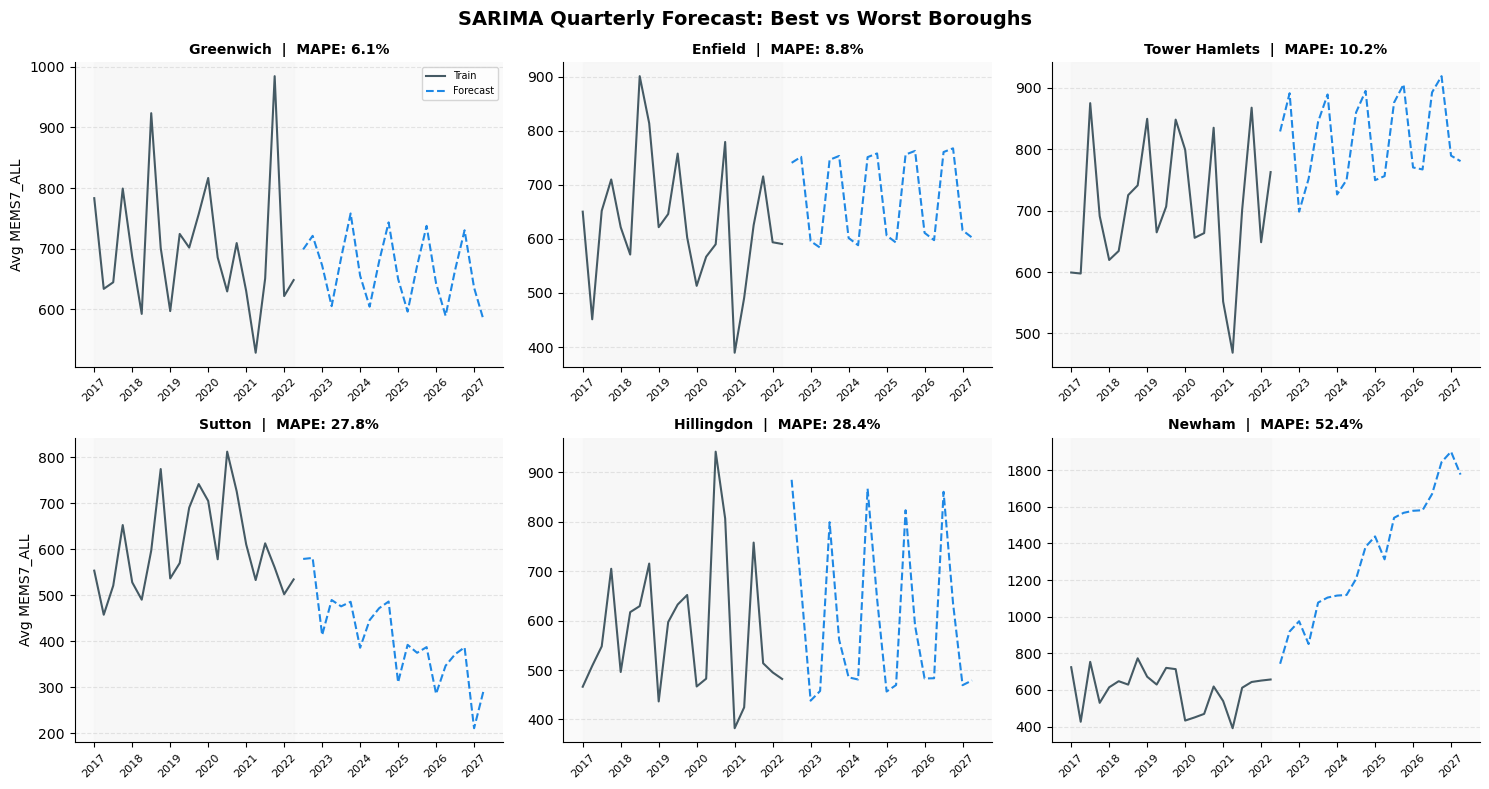

In [26]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('SARIMA Quarterly Forecast: Best vs Worst Boroughs', fontweight='bold', fontsize=14)

for i, (boroughs, label) in enumerate([(best_3, 'Best'), (worst_3, 'Worst')]):
    for j, borough in enumerate(boroughs):
        ax = axes[i, j]
        row = f2.sarima_forecast[f2.sarima_forecast['LA_Name'] == borough].iloc[0]
        
        y_train = np.array(row['y_train'])
        y_test = np.array(row['y_test'])
        y_forecast = np.array(row['y_forecast'])
        mape = row['mape']
        
        t_train = np.arange(len(y_train))
        t_test = np.arange(len(y_train), len(y_train) + len(y_test))
        t_forecast = np.arange(len(y_train), len(y_train) + len(y_forecast))
        
        ax.plot(t_train, y_train, color='#455A64', linewidth=1.5, label='Train')
        ax.plot(t_forecast, y_forecast, color='#1E88E5', linewidth=1.5, linestyle='--', label='Forecast')
        ax.axvspan(0, len(y_train)-1, alpha=0.08, color='#E0E0E0', zorder=0)
        
        ax.set_title(f'{borough}  |  MAPE: {mape:.1f}%', fontsize=10, fontweight='bold')
        ax.set_xticks(f2.ticks)
        ax.set_xticklabels(f2.labels, rotation=45, fontsize=8)
        ax.set_facecolor('#FAFAFA')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.grid(axis='y', alpha=0.3, linestyle='--')
        if j == 0:
            ax.set_ylabel('Avg MEMS7_ALL')
        if i == 0 and j == 0:
            ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig('best_worst_sarima_styled.png', dpi=150, bbox_inches='tight')
plt.show()

In [27]:
borough_mapes_yr = f3.bayesian_ridge_forecast[['LA_Name', 'mape']].sort_values('mape')
best_3_yr = borough_mapes_yr.head(3)['LA_Name'].tolist()
worst_3_yr = borough_mapes_yr.tail(3)['LA_Name'].tolist()
print("Best:", best_3_yr)
print("Worst:", worst_3_yr)

Best: ['Hillingdon', 'Bexley', 'Greenwich']
Worst: ['Newham', 'Tower Hamlets', 'Waltham Forest']


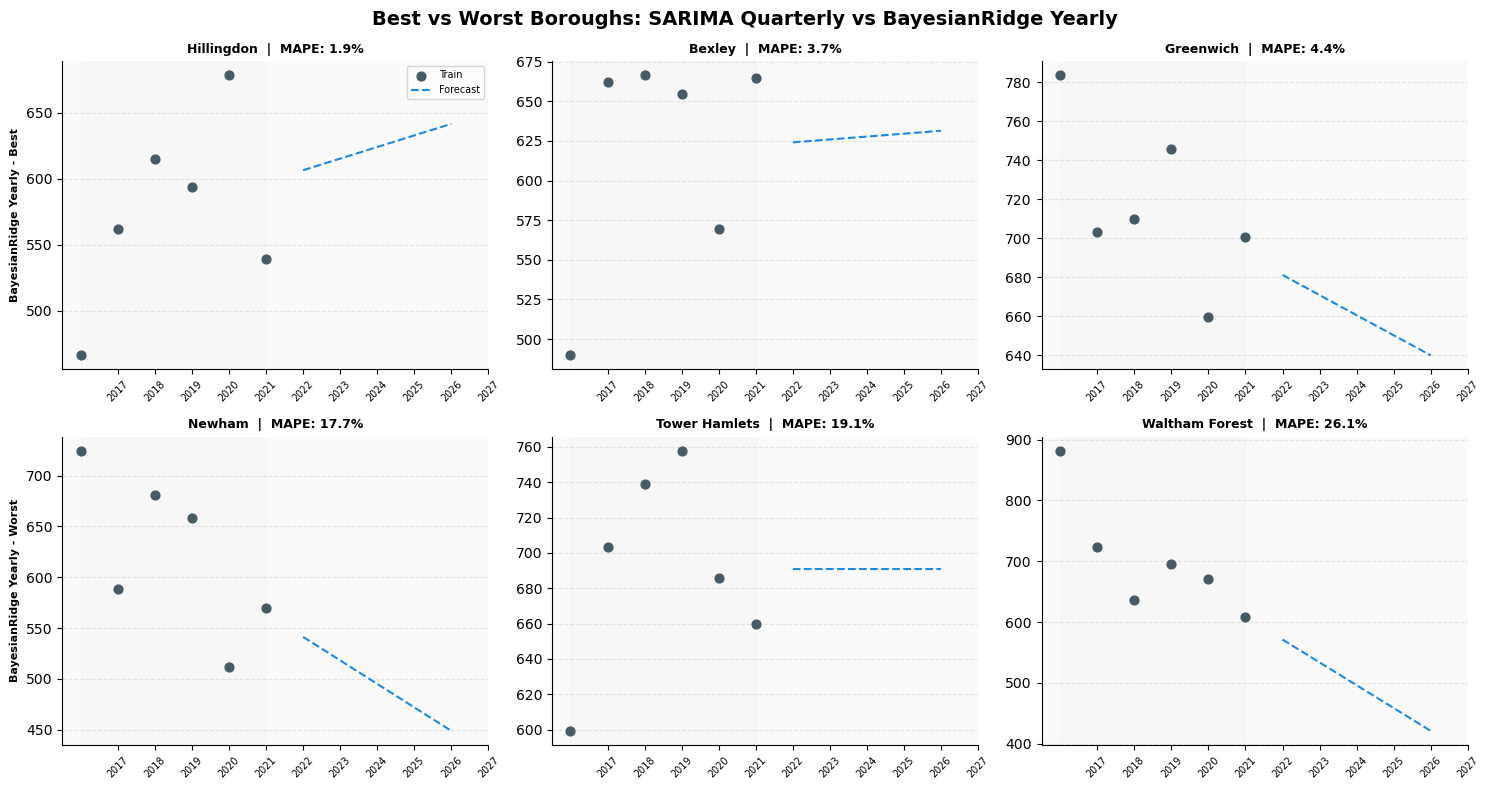

In [33]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Best vs Worst Boroughs: SARIMA Quarterly vs BayesianRidge Yearly', fontweight='bold', fontsize=14)

row_configs = [
    (best_3_yr, f3, 'bayesian_ridge', 'BayesianRidge Yearly - Best'),
    (worst_3_yr, f3, 'bayesian_ridge', 'BayesianRidge Yearly - Worst'),
]

for i, (boroughs, forecast_obj, method, row_label) in enumerate(row_configs):
    forecast_df = getattr(forecast_obj, f'{method}_forecast')
    for j, borough in enumerate(boroughs):
        ax = axes[i, j]
        row = forecast_df[forecast_df['LA_Name'] == borough].iloc[0]
        
        y_train = np.array(row['y_train'])
        y_forecast = np.array(row['y_forecast'])
        mape = row['mape']
        
        t_train = np.arange(len(y_train))
        t_forecast = np.arange(len(y_train), len(y_train) + len(y_forecast))
        
        ax.axvspan(0, len(y_train)-1, alpha=0.08, color='#E0E0E0', zorder=0)
        ax.scatter(t_train, y_train, color='#455A64', s=40, zorder=5, label='Train')
        ax.plot(t_forecast, y_forecast, color='#1E88E5', linewidth=1.5, linestyle='--', label='Forecast')       
        
        ax.set_title(f'{borough}  |  MAPE: {mape:.1f}%', fontsize=9, fontweight='bold')
        ax.set_xticks(forecast_obj.ticks)
        ax.set_xticklabels(forecast_obj.labels, rotation=45, fontsize=7)
        ax.set_facecolor('#FAFAFA')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.grid(axis='y', alpha=0.3, linestyle='--')
        
        if j == 0:
            ax.set_ylabel(row_label, fontsize=8, fontweight='bold')
        if i == 0 and j == 0:
            ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig('best_worst_comparison.png', dpi=150, bbox_inches='tight')
plt.show()